In [1]:
import numpy as np
import math
import pandas as pd
from scipy import signal
from scipy.ndimage import gaussian_filter1d
from scipy.stats import friedmanchisquare
from scipy.stats import pearsonr

import statsmodels.formula.api as smf

import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.colors import Normalize, ListedColormap
#import matplotlib.colormaps as cmaps
import matplotlib.cm as cm
import seaborn as sns
from matplotlib.lines import Line2D


import pingouin as pg

# Functions

In [2]:
def split_outbreak_size(curve, offset=0):
    """
    Splits a hospitalization curve into two halves and returns the total hospitalizations
    (outbreak size) in each half.

    Parameters:
    -----------
    curve : array-like
        1D array or list representing hospitalizations over time.
    offset: number of weeks offset from the middle of the period

    Returns:
    --------
    first_half_total : float
        Total hospitalizations in the first half of the curve.
    second_half_total : float
        Total hospitalizations in the second half of the curve.
    """
    curve = np.array(curve)
    n = len(curve)
    midpoint = n // 2

    first_half = curve[:midpoint+offset]
    second_half = curve[midpoint+offset:]

    first_half_total = np.sum(first_half)
    second_half_total = np.sum(second_half)

    return first_half_total, second_half_total

In [3]:
# Custom function to apply color coding to heatmaps
def custom_color_map_1(values):
    colors = []
    for val in values.flatten():
        if np.isnan(val):
            colors.append("#ffffff")  # white for NaN
        elif abs(val) <= 10:
            colors.append("lightgray")  # gray
        elif val < -10:
            colors.append("red")
        elif val > 10:
            colors.append("blue")
    return np.array(colors).reshape(values.shape)

In [4]:
# Note: get_cmaps will get deprecated so get rid of this soon
def custom_color_map_sqrt(values):
    # Apply sqrt transform preserving sign
    transformed = np.sign(values) * np.sqrt(np.abs(values))

    # Normalize centered around 0
    max_val = np.nanmax(np.abs(transformed))
    norm = Normalize(vmin=-max_val, vmax=max_val)
    cmap = cm.get_cmap("RdBu")

    colors = np.empty(values.shape, dtype=object)

    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            val = values[i, j]
            if np.isnan(val):
                colors[i, j] = "white"
            else:
                transformed_val = np.sign(val) * np.sqrt(abs(val))
                colors[i, j] = cmap(norm(transformed_val))

    return colors

# Input data

In [5]:
# Change file path as needed
df_samples = pd.read_csv("Data/combined_samples_all-teams_all-locations_all-scenarios_age-0-130.csv.gz", compression="gzip", low_memory=False)
locations = pd.read_csv("covid19-scenario-hub_r19_manuscript/data/data-locations/locations.csv", dtype = {'location':str})
locations_pop = pd.read_csv("locations_pop.csv")

# Analysis
## Calculate the two halves of the outbreaks per team per location per scenario
* Output is a pdf file with scatter plots of the summer and winter wave magnitudes and a .csv file where information regarding the two outbreak magnitudes is saved
* Considering all 8 teams

In [6]:
teams = np.array(['CFA-Scenarios','JHU_UNC-flepiMoP', 'UIUC-IMMCYC', 'PSI-M_CoV_2025',
       'UNCC-Hierbin', 'UVA-adaptive', 'MOBS_NEU-GLEAM_COVID', 'UT-ImmunoSEIRS'], dtype=object) # Including all teams for this
location=df_samples["location"].unique()

all_outbreaks = []
with PdfPages("outbreak_sizes_comp_all_teams_locs.pdf") as pdf:
    for team in teams:
        # Add title page for the team
        print(team)
        fig_title = plt.figure(figsize=(8, 6))
        fig_title.text(0.5, 0.5, f"Results for team: {team}", fontsize=24, ha='center', va='center')
        pdf.savefig(fig_title)
        plt.close(fig_title)
        
        for loc_ in location:

            df_subset = df_samples[(df_samples['location']==loc_) & (df_samples["team"]==team)]
            
            # Skip bad data
            if df_subset.empty or "value" not in df_subset.columns:
                print(f"Skipping {team} - {loc_}: missing or invalid data")
                continue

            # Select and reorder the relevant columns
            columns_order = ["scenario_id", "output_type_id", "value", "end_date"]
            df_reorder = df_subset[columns_order].copy()

            # Make sure end_date is datetime type
            df_reorder["end_date"] = pd.to_datetime(df_reorder["end_date"])

            # Sort by scenario, output_type, and time
            df_sorted = df_reorder.sort_values(by=["scenario_id", "output_type_id", "end_date"])

            # Get unique sorted values for axis indexing
            scenario_ids = sorted(df_sorted["scenario_id"].unique())
            output_type_ids = sorted(df_sorted["output_type_id"].unique())
            end_dates = sorted(df_sorted["end_date"].unique())  # assume all combinations exist for each (scenario, output_type)

            # Create a multi-indexed DataFrame
            pivot_df = df_sorted.pivot_table(
                index=["scenario_id", "output_type_id", "end_date"],
                values="value"
            ).reindex(
                pd.MultiIndex.from_product([scenario_ids, output_type_ids, end_dates], names=["scenario_id", "output_type_id", "end_date"])
            )

            # Reshape to 3D array: (n_scenarios, n_output_types, n_timepoints)
            array_3d = pivot_df["value"].values.reshape(len(scenario_ids), len(output_type_ids), len(end_dates))

            # Store results
            outbreak_sizes = []

            # Loop through all scenario-output_type combinations
            n_scenarios, n_outputs, n_time = array_3d.shape

            for i in range(n_scenarios):
                for j in range(n_outputs):
                    trajectory = array_3d[i, j, :]
                    first_half, second_half = split_outbreak_size(trajectory)
                    
                    outbreak_sizes.append({
                            "scenario_index": i,
                            "output_type_index": j,
                            "first_half": first_half,
                            "second_half": second_half
                        })
                    # Collate info across models and locations
                    all_outbreaks.append({
                            "team": team,
                            "scenario_id": scenario_ids[i],
                            "output_type_index": output_type_ids[j],
                            "location": loc_,
                            "first_half": first_half,
                            "second_half": second_half
                        })
 

            # Convert to DataFrame
            outbreaks_df = pd.DataFrame(outbreak_sizes)

            # Get unique scenario indices
            scenario_indices = sorted(peaks_df["scenario_index"].unique())
            n_scenarios = len(scenario_indices)

            # Determine subplot grid size (e.g., square-ish layout)
            ncols = math.ceil(math.sqrt(n_scenarios))
            nrows = math.ceil(n_scenarios / ncols)

            # Create subplots
            fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4*ncols, 4*nrows), sharex=True, sharey=True)

            # Flatten axes array for easy indexing
            axes = axes.flatten()

            for idx, scenario_idx in enumerate(scenario_indices):
                ax = axes[idx]
                group = outbreaks_df[outbreaks_df["scenario_index"] == scenario_idx]
                x = group["first_half"].values
                y = group["second_half"].values

                # Masks
                winter_mask = x < y    # Last (winter) outbreak is larger
                summer_mask = x > y  # First (summer) outbreak is larger

                # Plot points
                ax.scatter(x[winter_mask], y[winter_mask], color="blue", alpha=0.7)
                ax.scatter(x[summer_mask], y[summer_mask], color="red", alpha=0.7)

                # Filter out invalid or zero-only data
                mask = (x > 0) & (y > 0)
                
                if mask.sum() >= 10:
                    x_valid = x[mask]
                    y_valid = y[mask]
                    slope, intercept = np.polyfit(x_valid, y_valid, 1)
                    
                    # Plot line of best fit
                    x_line = np.linspace(min(x_valid), max(x_valid), 100)
                    y_line = slope * x_line + intercept
                    ax.plot(x_line, y_line, color='black')


                ax.set_title(f"{scenario_ids[idx]}")
                ax.set_xlabel("Summer outbreak")
                ax.set_ylabel("Winter outbreak")

                # Annotate with line of best fit
                ax.text(
                    0.05, 0.95,
                    f'Fit: y={slope:.2f}x+{intercept:.2f}',
                    transform=ax.transAxes,
                    fontsize=9,
                    verticalalignment='top',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.6)
                )

            # Hide unused subplots
            for j in range(len(scenario_indices), len(axes)):
                axes[j].set_visible(False)

            # Legend (global)
            handles = [
                plt.Line2D([0], [0], marker='o', color='w', label="Winter > Summer", markerfacecolor='blue', markersize=8),
                plt.Line2D([0], [0], marker='o', color='w', label="Summer > Winter", markerfacecolor='red', markersize=8)
            ]
            fig.legend(handles=handles, loc='upper right', bbox_to_anchor=(1.12, 0.95))


            # Get the state abbr. for the loc variable
            abbr = locations.loc[locations["location"] == loc_, "abbreviation"].values
            plt.suptitle(f"Comparing outbreak magnitudes per scenario for {abbr}", fontsize=16)
            plt.tight_layout(rect=[0, 0.03, 1, 0.95])
            pdf.savefig(fig, bbox_inches='tight')
            plt.close(fig)
            
            del pivot_df
            del df_subset
            
# Save peak info summary
df_all_peaks = pd.DataFrame(all_outbreaks)
df_all_peaks.to_csv("outbreak_magnitudes_summary.csv", index=False)

CFA-Scenarios
Skipping CFA-Scenarios - 11: missing or invalid data
JHU_UNC-flepiMoP
UIUC-IMMCYC
PSI-M_CoV_2025
UNCC-Hierbin
UVA-adaptive
MOBS_NEU-GLEAM_COVID
UT-ImmunoSEIRS
Skipping UT-ImmunoSEIRS - 11: missing or invalid data


## For the summer and winter wave sizes scatter plot calculate the line of best fit by team, location and scenario and create a colored grid for visualization

In [8]:
# Load the summary CSV 
df = pd.read_csv("outbreak_magnitudes_summary.csv", dtype = {'location':str}) 
results_slopes_scenarios = [] 

for (team, location, scenario), group in df.groupby(["team", "location", "scenario_id"]): 
    x = group["first_half"].values 
    y = group["second_half"].values 
    
    # Remove any invalid or zero-only data to avoid divide-by-zero 
    mask = (x > 0) & (y > 0) 
    if mask.sum() < 10: 
        slope = np.nan 
        intercept = np.nan 
        corr = np.nan 
        pval = np.nan 
    else: 
        x_valid = x[mask] 
        y_valid = y[mask] 
        slope, intercept = np.polyfit(x_valid, y_valid, 1) 
        corr, pval = pearsonr(x_valid, y_valid) 
        
    results_slopes_scenarios.append({ 
        "team": team, 
        "location": location, 
        "scenario_id": scenario, 
        "slope": slope, 
        "intercept": intercept, 
        "correlation": corr, 
        "p_value": pval 
    })

# Convert results to DataFrame if needed
slope_df_scenarios = pd.DataFrame(results_slopes_scenarios)
slope_df_scenarios.to_csv("outbreak_slopes_results.csv", index=False)

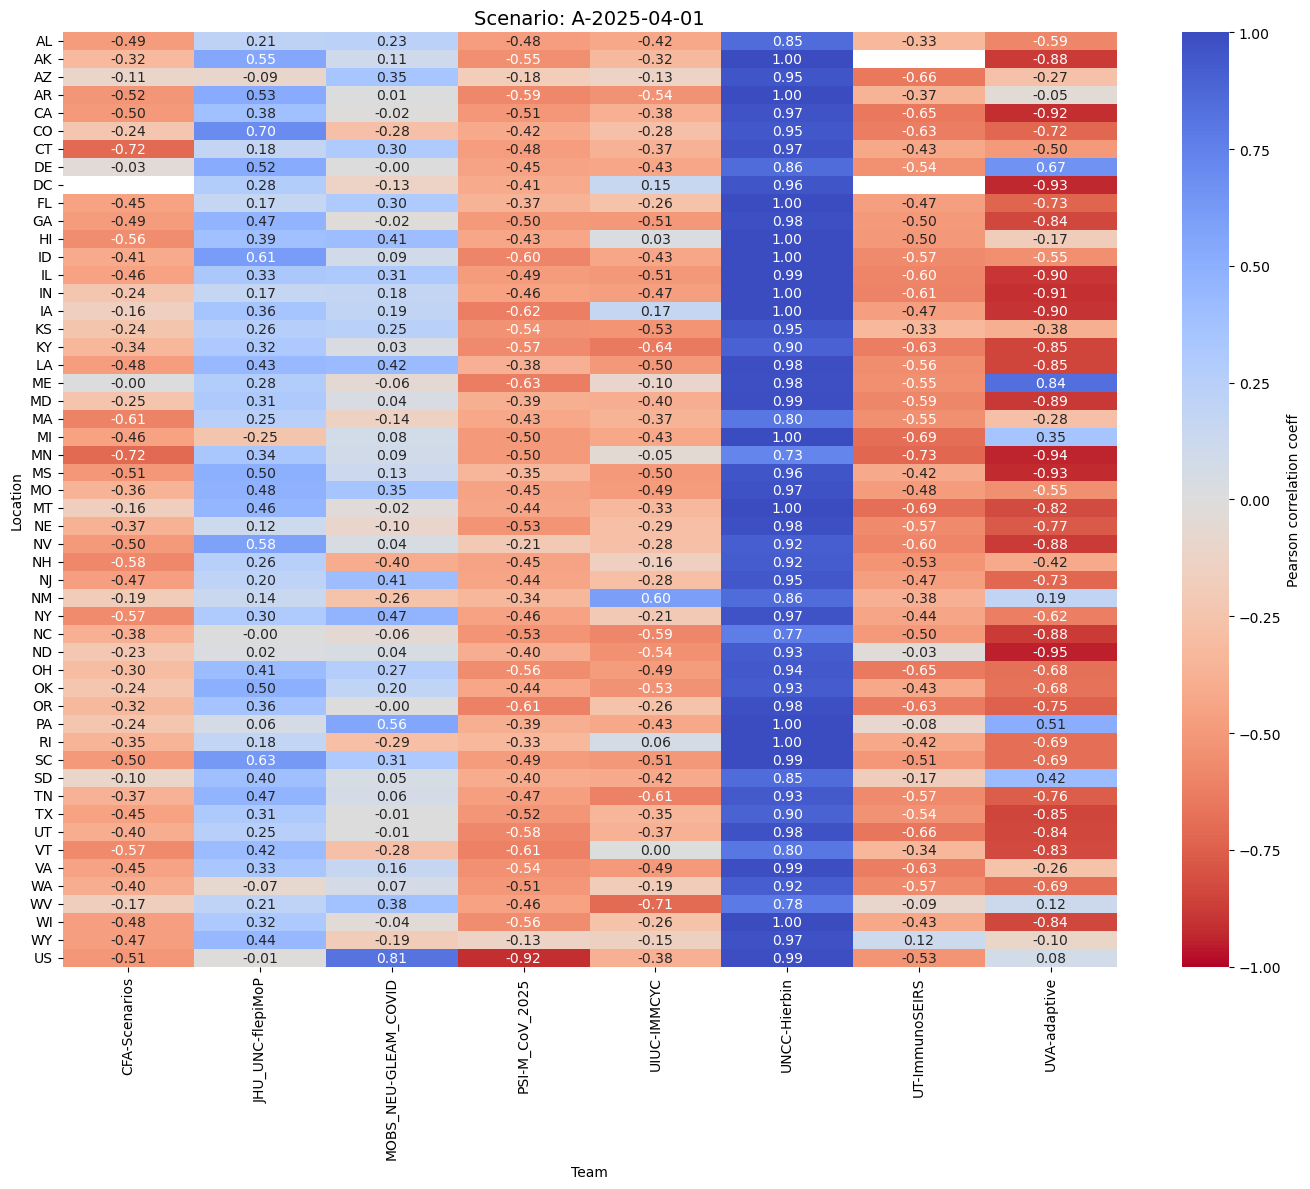

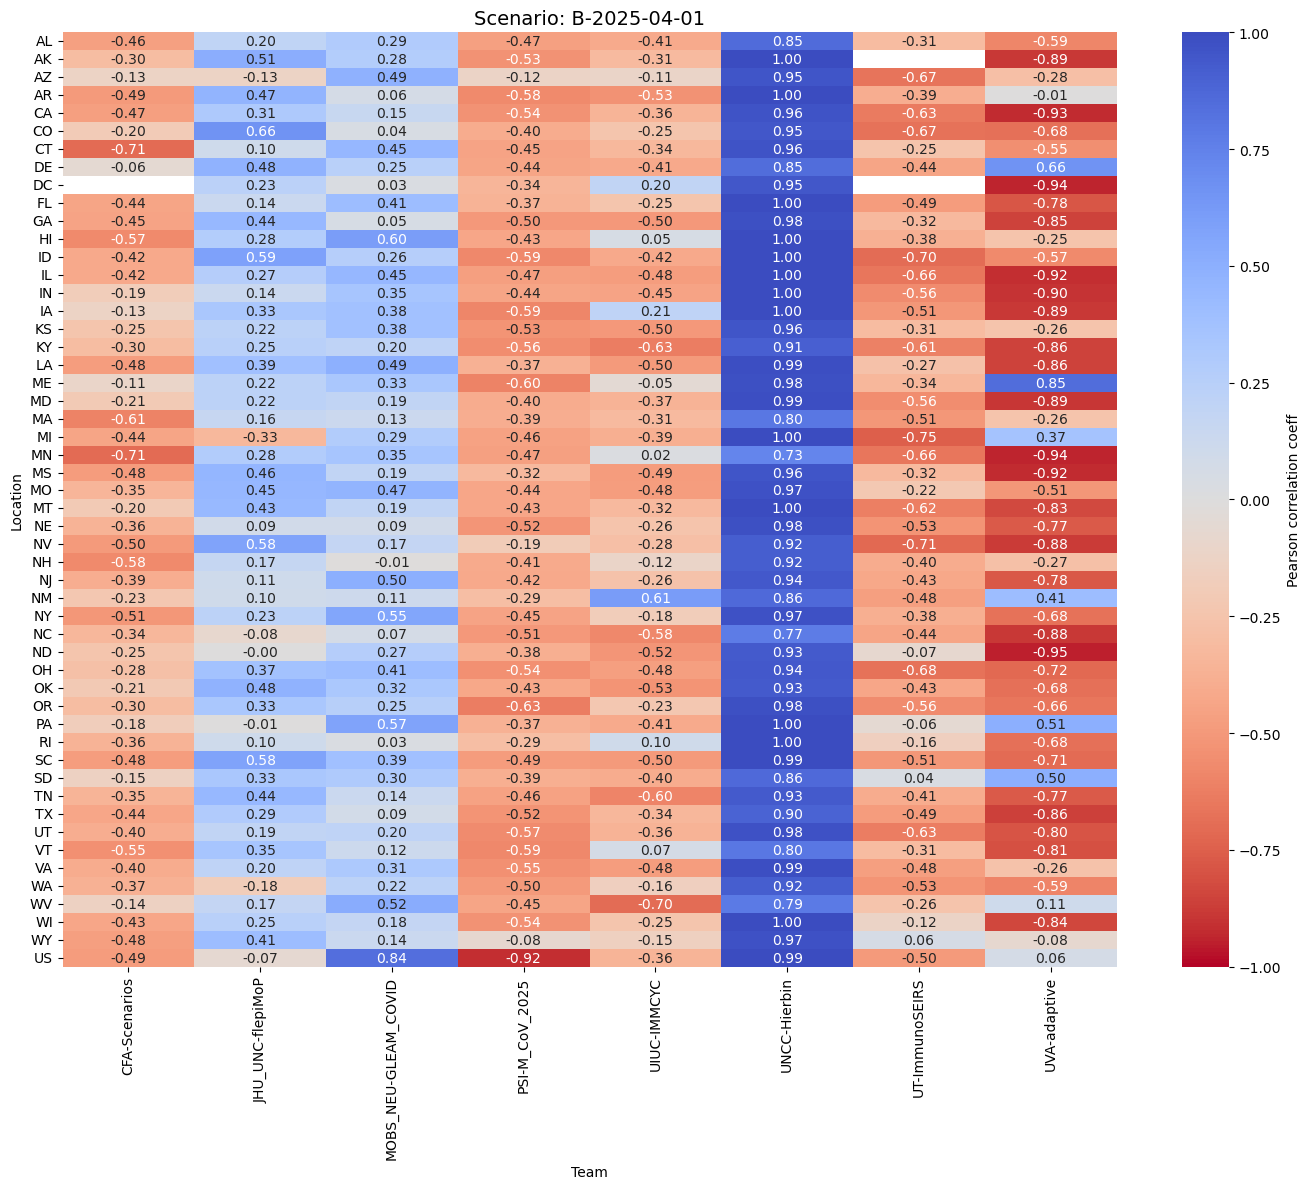

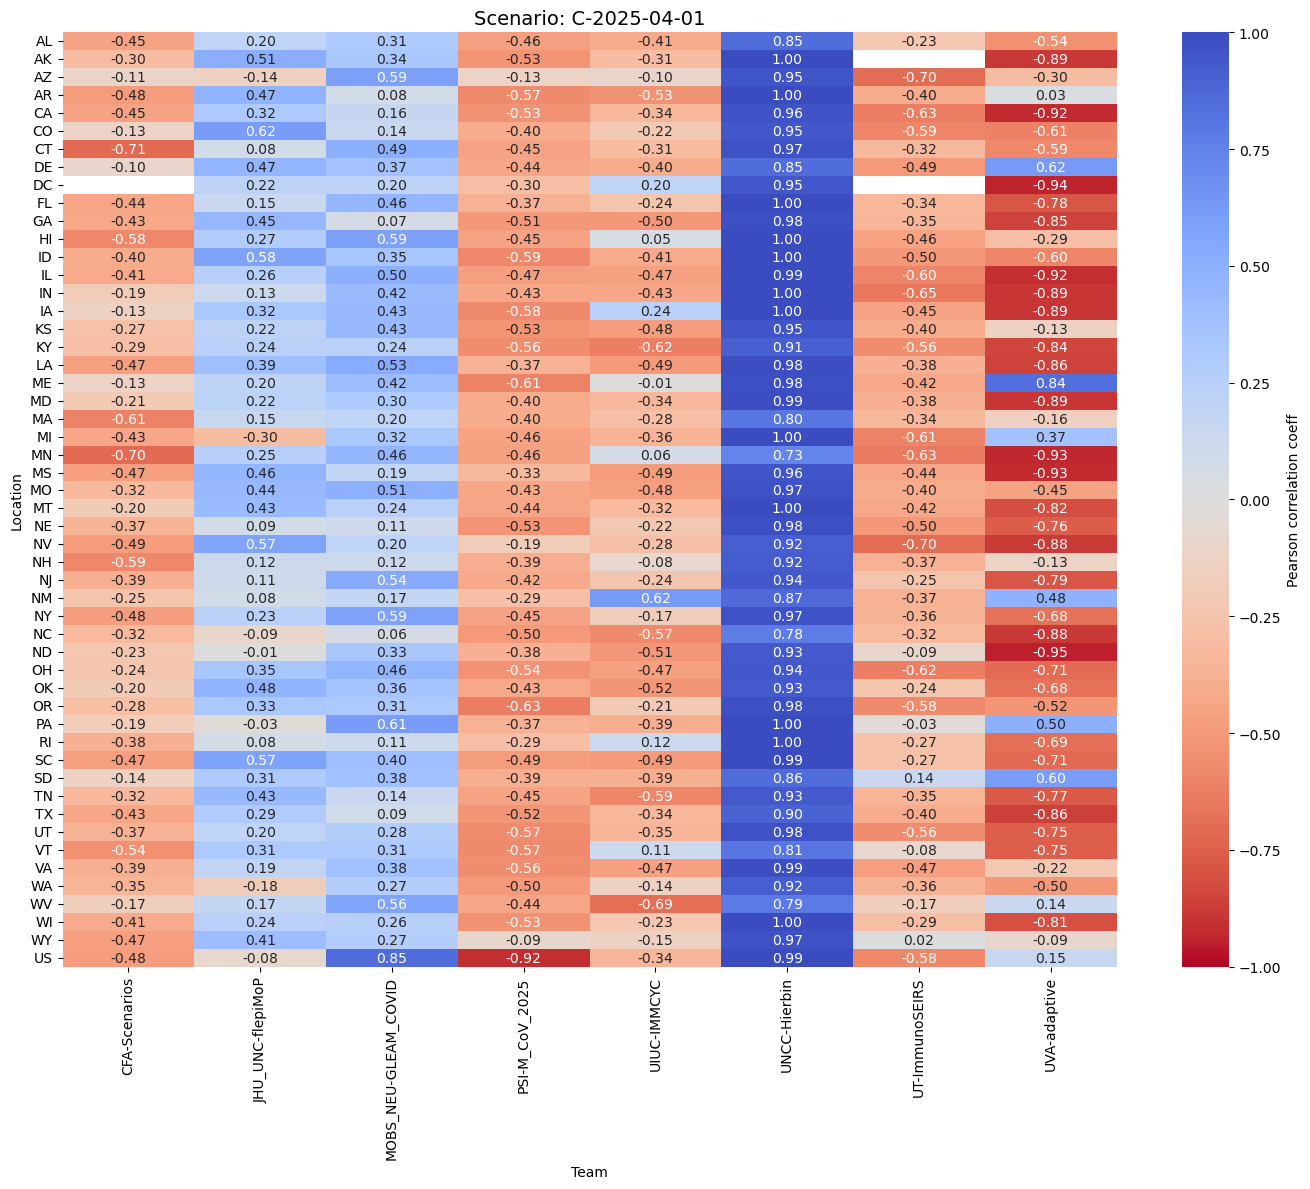

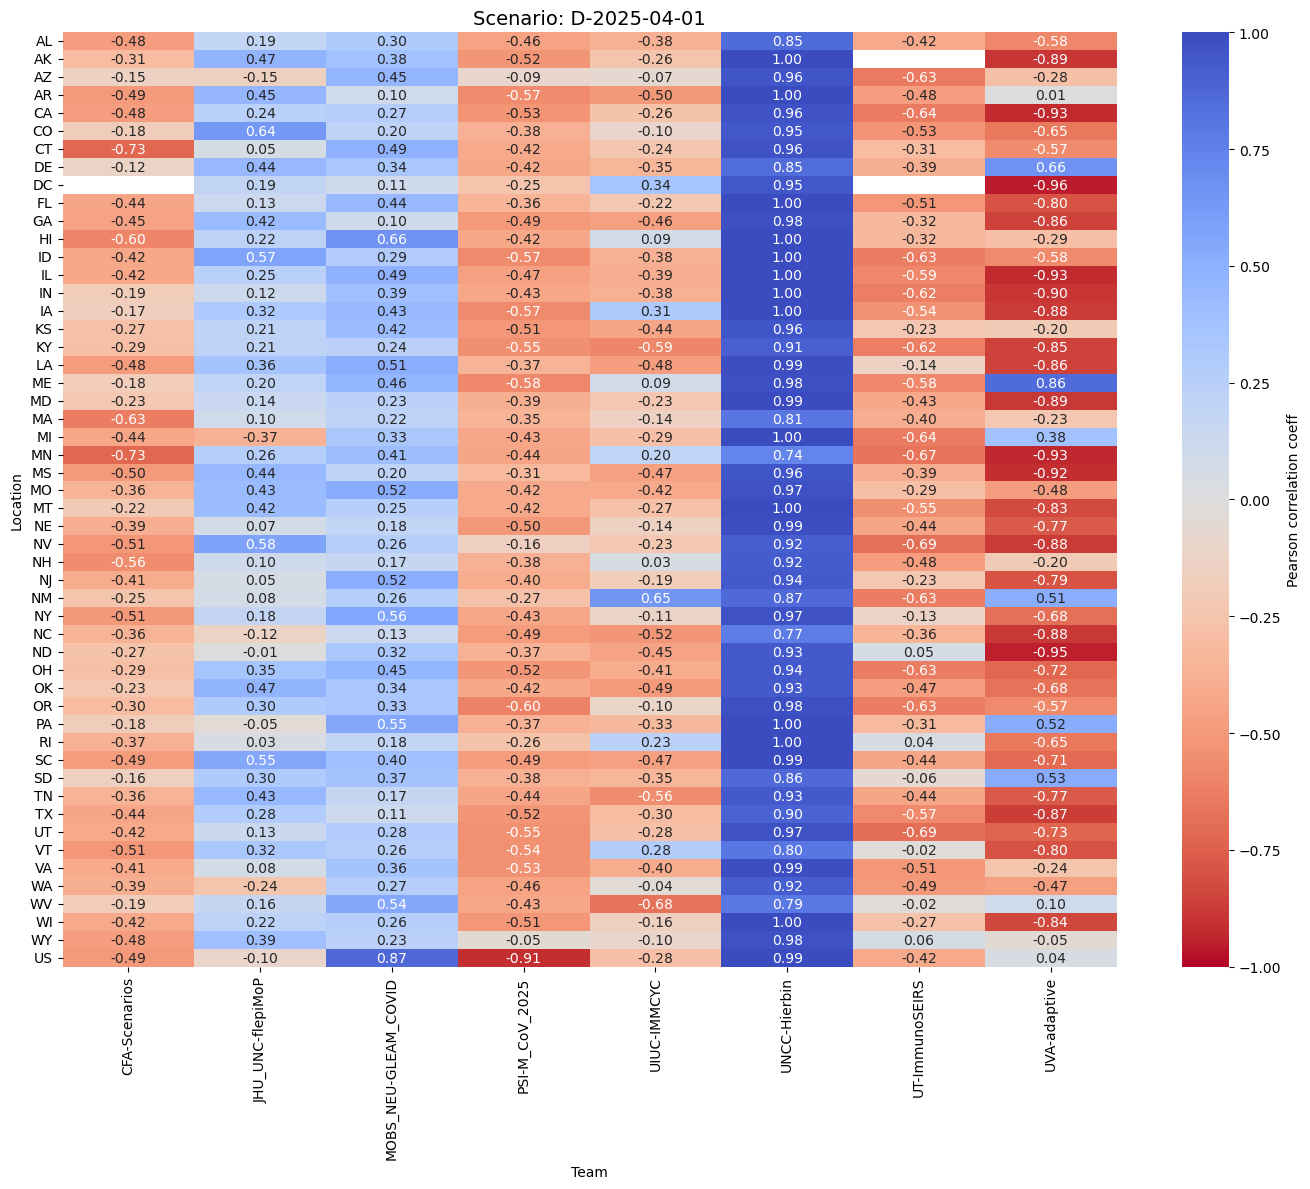

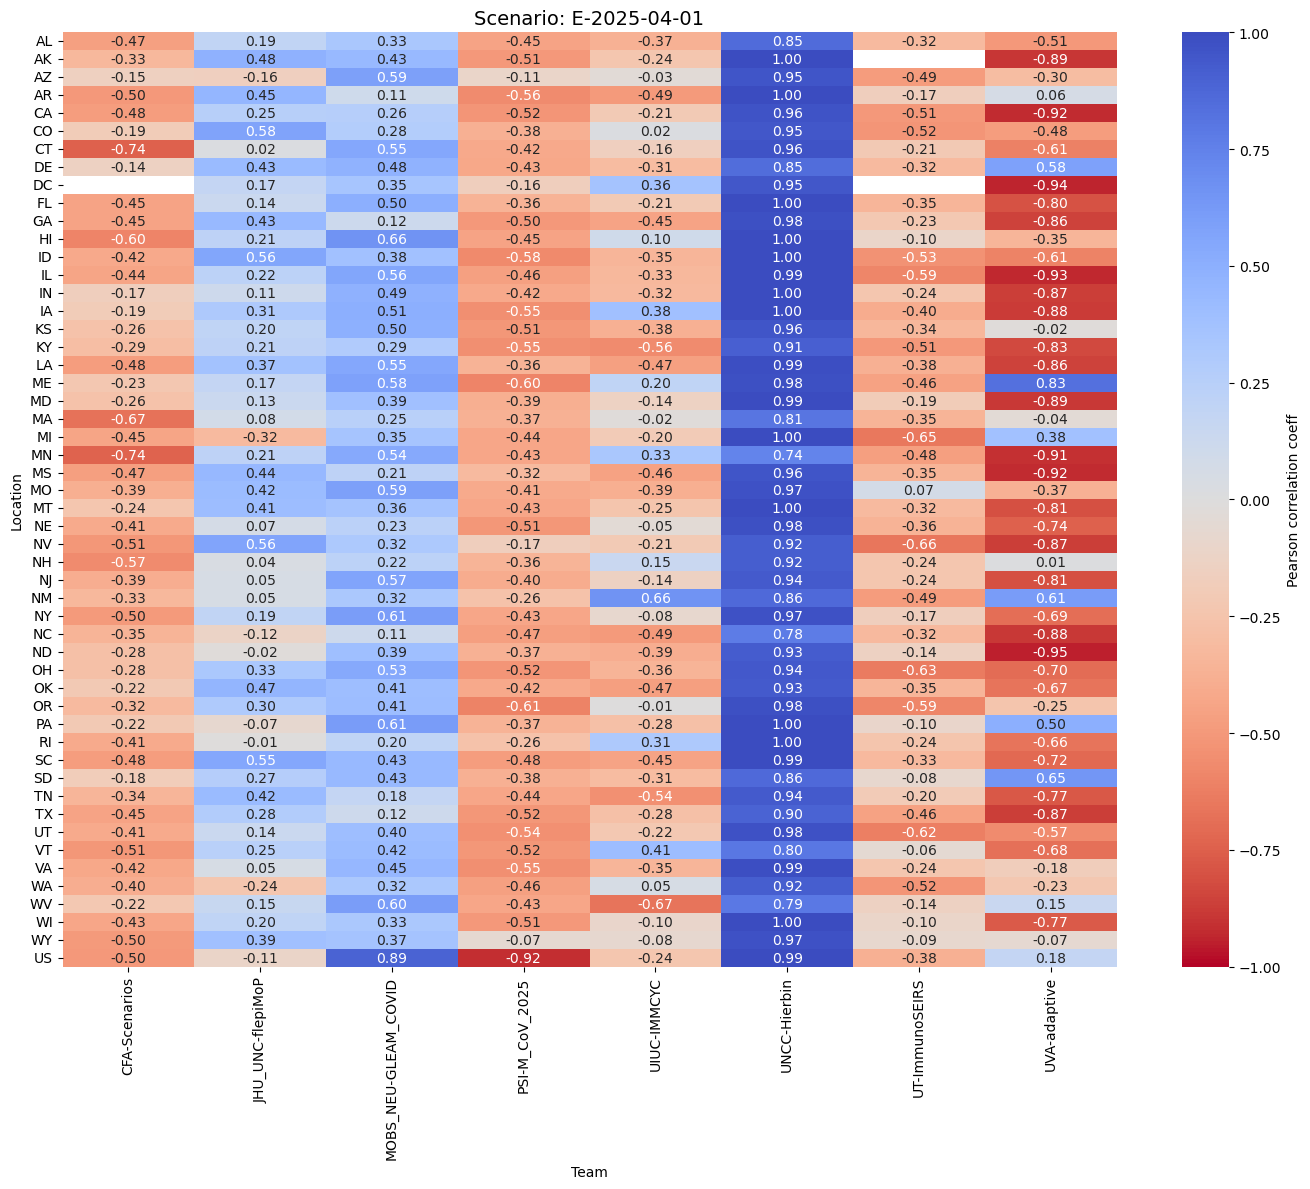

In [9]:
# Pearson's correlation of best-fit line
# Loop over each scenario_id
for scenario in slope_df_scenarios["scenario_id"].unique():
    # Filter for current scenario
    df_scenario = slope_df_scenarios[slope_df_scenarios["scenario_id"] == scenario]

    # Pivot to make team x location matrix
    heatmap_data = df_scenario.pivot(index="location", columns="team", values="correlation")
    
    # Map location names to abbreviations
    abbr_map = dict(zip(locations["location"], locations["abbreviation"]))
    heatmap_data.index = heatmap_data.index.map(abbr_map)  

    # Set up the figure
    plt.figure(figsize=(14, 12))

    # Create the heatmap
    sns.heatmap(
        heatmap_data,
        annot=True, fmt=".2f", cmap="coolwarm_r", center=0.0,
        vmin=-1, vmax=1,  # symmetric color scale around 0
        cbar_kws={'label': 'Pearson correlation coeff'},
        linewidths=0,
        linecolor='white',
    )

    # Labels and title
    plt.title(f"Scenario: {scenario}", fontsize=14)
    plt.xlabel("Team")
    plt.ylabel("Location")

    # Save and show
    plt.tight_layout()
    plt.savefig(f"outbreak_corr_heatmap_{scenario}.pdf", bbox_inches='tight')
    plt.show()

## Mixed-effects analysis per team separating out locations where in scenario A their mean difference (winter wave - summer wave) was positive or negative

In [6]:
# Load the summary CSV
df = pd.read_csv("outbreak_magnitudes_summary.csv", dtype = {'location':str})

# Compute difference between the winter and summer peaks
df["outbreak_diff"] = df["second_half"] - df["first_half"]

# Compute outbreak size
df['outbreak_size'] = df["second_half"] + df["first_half"]

# Merge population data into main dataframe
df = df.merge(locations_pop[["location", "population"]], on="location", how="left")

# Compute population-normalized outbreak difference (per 100k)
df["outbreak_diff_per_100k"] = df["outbreak_diff"] / df["population"] * 1e5

# Compute population-normalized outbreak size (per 100k)
df["total_outbreak_size_per_100k"] = df["outbreak_size"] / df["population"] * 1e5

# Population normalized summer and winter outbreaks
df["winter_outbreak_size_per_100k"] = df["second_half"] / df["population"] * 1e5
df["summer_outbreak_size_per_100k"] = df["first_half"] / df["population"] * 1e5

In [7]:
# Create a column that classifies each location for each team as being summer leaning or winter leaning based on
# the mean diff. in outbreak sizes in Scenario A

# Step 1: Filter for scenario_id 'A'
df_A = df[df['scenario_id'] == 'A-2025-04-01']

# Step 2: Compute mean outbreak_diff for each (team, location) over output_type_index
mean_diff = df_A.groupby(['team', 'location'])['outbreak_diff'].mean()

# Step 3: Classify as 1 or -1 based on the sign of the mean
classification = mean_diff.apply(lambda x: 'winter' if x > 0 else 'summer')

# Step 4: Map the classification back to the original dataframe
df['classify_outbreak'] = df.set_index(['team', 'location']).index.map(classification)

### Effect on the total outbreak size

In [10]:
teams = df["team"].unique()
loc_classes = ['summer','winter']
colors_dict = {'summer':'red','winter':'blue'}
y_max = [70,70,120,16,40,50,90,18]
team_idx = 0

# Store results by loc_class
results_dict = {loc_class: [] for loc_class in loc_classes}

with PdfPages("fixed_effect_outbreak_size.pdf") as pdf:
    for team in teams:
        fig, ax = plt.subplots(figsize=(10, 6))

        for loc_class in loc_classes:
            df_team = df[(df["team"] == team) & (df["classify_outbreak"] == loc_class)]

            try:
                # Fit mixed effects model
                model = smf.mixedlm("total_outbreak_size_per_100k ~ scenario_id", data=df_team, groups=df_team["location"])
                result = model.fit(method="powell")

                print(f"\n=== Mixed effects model summary for team {team} and location class {loc_class} ===")
                print(result.summary())

                coefs = result.params.filter(like="scenario_id")
                errors = result.bse.filter(like="scenario_id")

                # Save per-team results
                temp_df = pd.DataFrame({
                    "team": team,
                    "scenario": coefs.index,
                    "estimate": coefs.values,
                    "std_error": errors.values
                })
                results_dict[loc_class].append(temp_df)

                # Plot with label for the legend
                plt.errorbar(coefs.index, np.abs(coefs.values), yerr=1.96 * errors.values, fmt='o', label=f'{loc_class} leaning', color=colors_dict[loc_class])

            except Exception as e:
                print(f"Could not fit model for team {team}, class {loc_class}: {e}")

        # Finalize plot for this team
        ax.axhline(0, color='gray', linestyle='--')
        plt.xticks(rotation=45)
        ax.set_ylabel("Number of hospitalizations averted \n per 100k", fontsize=16)
        ax.set_title(f"Scenario effects with 95% CI for team {team}")
        ax.legend(title="Location type", fontsize=12, title_fontsize=13)

        # Set y-axis range: min per team, max at 0
        ax.set_ylim(-0.1, y_max[team_idx])

        # Optional: set nice tick intervals (e.g., 5–7 ticks)
        ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=6))

        # Increase label size
        ax.tick_params(axis='y', labelsize=14)

        plt.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)
        team_idx += 1

# Save results tables
for loc_class in loc_classes:
    if results_dict[loc_class]:
        combined_df = pd.concat(results_dict[loc_class], ignore_index=True)
        combined_df.to_csv(f"fixed_effects_outbreak_size_class_{loc_class}.csv", index=False)


=== Mixed effects model summary for team CFA-Scenarios and location class summer ===
                   Mixed Linear Model Regression Results
Model:              MixedLM Dependent Variable: total_outbreak_size_per_100k
No. Observations:   64500   Method:             REML                        
No. Groups:         43      Scale:              99.8540                     
Min. group size:    1500    Log-Likelihood:     -240213.8092                
Max. group size:    1500    Converged:          Yes                         
Mean group size:    1500.0                                                  
----------------------------------------------------------------------------
                             Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
----------------------------------------------------------------------------
Intercept                    250.804    7.000   35.829 0.000 237.084 264.523
scenario_id[T.B-2025-04-01]  -26.677    0.124 -214.404 0.000 -26.921 -26.433
scenario_i


=== Mixed effects model summary for team PSI-M_CoV_2025 and location class summer ===
                   Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: total_outbreak_size_per_100k
No. Observations:  36000   Method:             REML                        
No. Groups:        24      Scale:              2123.2791                   
Min. group size:   1500    Log-Likelihood:     -189059.4547                
Max. group size:   1500    Converged:          Yes                         
Mean group size:   1500.0                                                  
---------------------------------------------------------------------------
                             Coef.   Std.Err.    z    P>|z|  [0.025  0.975]
---------------------------------------------------------------------------
Intercept                    219.031   11.550  18.964 0.000 196.393 241.668
scenario_id[T.B-2025-04-01]  -10.147    0.768 -13.212 0.000 -11.652  -8.642
scenario_id[T.C-2025


=== Mixed effects model summary for team MOBS_NEU-GLEAM_COVID and location class winter ===
                   Mixed Linear Model Regression Results
Model:              MixedLM Dependent Variable: total_outbreak_size_per_100k
No. Observations:   78000   Method:             REML                        
No. Groups:         52      Scale:              3769.3318                   
Min. group size:    1500    Log-Likelihood:     -431993.3530                
Max. group size:    1500    Converged:          Yes                         
Mean group size:    1500.0                                                  
----------------------------------------------------------------------------
                             Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
----------------------------------------------------------------------------
Intercept                    223.509    5.967   37.455 0.000 211.813 235.204
scenario_id[T.B-2025-04-01]  -53.063    0.695  -76.332 0.000 -54.425 -51.700
sce

In [9]:
# Calculate summary statistics
# Load both location classes
df_summer = pd.read_csv("fixed_effects_outbreak_size_class_summer.csv")
df_winter = pd.read_csv("fixed_effects_outbreak_size_class_winter.csv")

# Merge on team and scenario to align pairs
merged = pd.merge(
    df_winter, df_summer,
    on=["team", "scenario"],
    suffixes=("_winter", "_summer")
)

# Compute difference in estimates (winter - summer)
merged["diff_estimate"] = np.abs(merged["estimate_winter"] - merged["estimate_summer"])

# Now summarize across teams for each scenario
summary = (
    merged.groupby("scenario", as_index=False)
    .agg(
        mean_diff=("diff_estimate", "mean"),
        sd_diff=("diff_estimate", "std")
    )
)

# Save summary
summary.to_csv("fixed_effects_summary_outbreak_size_difference.csv", index=False)

### Effect on summer wave size

In [12]:
teams = df["team"].unique()
loc_classes = ['summer','winter']
colors_dict = {'summer':'red','winter':'blue'}
y_max = [70,70,120,16,40,50,90,18]
team_idx = 0

# Store results by loc_class
results_dict = {loc_class: [] for loc_class in loc_classes}

with PdfPages("fixed_effect_summer_size.pdf") as pdf:
    for team in teams:
        fig, ax = plt.subplots(figsize=(10, 6))

        for loc_class in loc_classes:
            df_team = df[(df["team"] == team) & (df["classify_outbreak"] == loc_class)]

            try:
                # Fit mixed effects model
                model = smf.mixedlm("summer_outbreak_size_per_100k ~ scenario_id", data=df_team, groups=df_team["location"])
                result = model.fit(method="powell")

                print(f"\n=== Mixed effects model summary for team {team} and location class {loc_class} ===")
                print(result.summary())

                coefs = result.params.filter(like="scenario_id")
                errors = result.bse.filter(like="scenario_id")

                # Save per-team results
                temp_df = pd.DataFrame({
                    "team": team,
                    "scenario": coefs.index,
                    "estimate": coefs.values,
                    "std_error": errors.values
                })
                results_dict[loc_class].append(temp_df)

                # Plot with label for the legend
                plt.errorbar(coefs.index, np.abs(coefs.values), yerr=1.96 * errors.values, fmt='o', label=f'{loc_class} leaning', color=colors_dict[loc_class])

            except Exception as e:
                print(f"Could not fit model for team {team}, class {loc_class}: {e}")

        # Finalize plot for this team
        ax.axhline(0, color='gray', linestyle='--')
        plt.xticks(rotation=45)
        ax.set_ylabel("Number of hospitalizations averted \n per 100k", fontsize=16)
        ax.set_title(f"Scenario effects with 95% CI for team {team}")
        ax.legend(title="Location type", fontsize=12, title_fontsize=13)

        # Set y-axis range: min per team, max at 0
        ax.set_ylim(-0.1, y_max[team_idx])

        # Optional: set nice tick intervals (e.g., 5–7 ticks)
        ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=6))

        # Increase label size
        ax.tick_params(axis='y', labelsize=14)

        plt.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)
        team_idx += 1

# Save results tables
for loc_class in loc_classes:
    if results_dict[loc_class]:
        combined_df = pd.concat(results_dict[loc_class], ignore_index=True)
        combined_df.to_csv(f"fixed_effects_summer_size_class_{loc_class}.csv", index=False)


=== Mixed effects model summary for team CFA-Scenarios and location class summer ===
                   Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: summer_outbreak_size_per_100k
No. Observations: 64500   Method:             REML                         
No. Groups:       43      Scale:              53.2433                      
Min. group size:  1500    Log-Likelihood:     -219925.3182                 
Max. group size:  1500    Converged:          Yes                          
Mean group size:  1500.0                                                   
---------------------------------------------------------------------------
                             Coef.  Std.Err.    z     P>|z|  [0.025  0.975]
---------------------------------------------------------------------------
Intercept                   137.707    4.024   34.223 0.000 129.821 145.594
scenario_id[T.B-2025-04-01]  -5.594    0.091  -61.574 0.000  -5.772  -5.416
scenario_id[T.C-2025-


=== Mixed effects model summary for team PSI-M_CoV_2025 and location class summer ===
                   Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: summer_outbreak_size_per_100k
No. Observations: 36000   Method:             REML                         
No. Groups:       24      Scale:              2128.1653                    
Min. group size:  1500    Log-Likelihood:     -189089.7923                 
Max. group size:  1500    Converged:          Yes                          
Mean group size:  1500.0                                                   
---------------------------------------------------------------------------
                             Coef.   Std.Err.    z    P>|z|  [0.025  0.975]
---------------------------------------------------------------------------
Intercept                    125.935    7.168  17.569 0.000 111.886 139.984
scenario_id[T.B-2025-04-01]   -5.293    0.769  -6.884 0.000  -6.800  -3.786
scenario_id[T.C-2025


=== Mixed effects model summary for team MOBS_NEU-GLEAM_COVID and location class winter ===
                   Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: summer_outbreak_size_per_100k
No. Observations: 78000   Method:             REML                         
No. Groups:       52      Scale:              670.3479                     
Min. group size:  1500    Log-Likelihood:     -364643.3348                 
Max. group size:  1500    Converged:          Yes                          
Mean group size:  1500.0                                                   
---------------------------------------------------------------------------
                                Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------
Intercept                       28.889    2.198  13.143 0.000 24.581 33.197
scenario_id[T.B-2025-04-01]     -0.696    0.293  -2.374 0.018 -1.271 -0.121
scenario_id[T.

#### Average difference in effect between winter and summer dominant locations

In [16]:
# Load both location classes
df_summer = pd.read_csv("fixed_effects_summer_size_class_summer.csv")
df_winter = pd.read_csv("fixed_effects_summer_size_class_winter.csv")

# Calculate avg. effect on winter - summer locations
# Merge on team and scenario to align pairs
merged = pd.merge(
    df_winter, df_summer,
    on=["team", "scenario"],
    suffixes=("_winter", "_summer")
)

# Compute difference in estimates (winter - summer)
merged["diff_estimate"] = np.abs(merged["estimate_winter"] - merged["estimate_summer"])

# Now summarize across teams for each scenario
summary = (
    merged.groupby("scenario", as_index=False)
    .agg(
        mean_diff=("diff_estimate", "mean"),
        sd_diff=("diff_estimate", "std")
    )
)

# Save summary
summary.to_csv("fixed_effects_summary_summer_size_difference.csv", index=False)

#### Average difference in effect between scenarios

In [27]:
loc_classes = ['summer','winter']

for loc_class in loc_classes:
    df = pd.read_csv(f"fixed_effects_summer_size_class_{loc_class}.csv")

    # Take absolute value of estimates
    df["estimate"] = df["estimate"].abs()

    # Extract the scenario letter (B, C, D, etc.) for easier handling
    df["scenario_label"] = df["scenario"].str.extract(r"\[T\.([A-Z])")

    # Pivot so each team has columns for each scenario
    df_wide = df.pivot_table(index="team", columns="scenario_label", values="estimate")

    # Compute the differences: (C - B) and (D - B)
    df_wide["diff_C_B"] = df_wide["C"] - df_wide["B"]
    df_wide["diff_D_B"] = df_wide["D"] - df_wide["B"]

    # Compute summary statistics across teams
    summary = pd.DataFrame({
        "comparison": ["C - B", "D - B"],
        "mean_difference": [df_wide["diff_C_B"].mean(), df_wide["diff_D_B"].mean()],
        "std_difference": [df_wide["diff_C_B"].std(), df_wide["diff_D_B"].std()]
    })

    # Save summary to CSV
    #summary.to_csv("scenario_differences_summary.csv", index=False)

    print(f"Result for {loc_class} leaning")
    print(summary)

Result for summer leaning
  comparison  mean_difference  std_difference
0      C - B         7.571893        4.674550
1      D - B         0.778296        0.427232
Result for winter leaning
  comparison  mean_difference  std_difference
0      C - B         5.799053        4.939684
1      D - B         0.867200        0.827774


In [28]:
df_wide

scenario_label,B,C,D,E,diff_C_B,diff_D_B
team,,,,,,
CFA-Scenarios,8.925368,20.893220,11.356337,28.099863,11.967852,2.430968
JHU_UNC-flepiMoP,3.428481,8.263867,3.823944,9.631791,4.835386,0.395463
MOBS_NEU-GLEAM_COVID,0.696059,3.232666,0.830575,3.969755,2.536607,0.134516
PSI-M_CoV_2025,4.858199,7.607769,5.108975,8.468267,2.749570,0.250776
UIUC-IMMCYC,8.773877,23.392422,10.293679,29.518288,14.618545,1.519802
UNCC-Hierbin,2.347814,4.693907,2.582153,5.818316,2.346093,0.234340
UT-ImmunoSEIRS,1.343514,2.453536,1.906777,3.785124,1.110021,0.563263
UVA-adaptive,3.732264,9.960615,5.140735,14.181077,6.228351,1.408471


### Effect on winter wave size

In [13]:
teams = df["team"].unique()
loc_classes = ['summer','winter']
colors_dict = {'summer':'red','winter':'blue'}
y_max = [70,70,120,16,40,50,90,18]
team_idx = 0

# Store results by loc_class
results_dict = {loc_class: [] for loc_class in loc_classes}

with PdfPages("fixed_effect_winter_size.pdf") as pdf:
    for team in teams:
        fig, ax = plt.subplots(figsize=(10, 6))

        for loc_class in loc_classes:
            df_team = df[(df["team"] == team) & (df["classify_outbreak"] == loc_class)]

            try:
                # Fit mixed effects model
                model = smf.mixedlm("winter_outbreak_size_per_100k ~ scenario_id", data=df_team, groups=df_team["location"])
                result = model.fit(method="powell")

                print(f"\n=== Mixed effects model summary for team {team} and location class {loc_class} ===")
                print(result.summary())

                coefs = result.params.filter(like="scenario_id")
                errors = result.bse.filter(like="scenario_id")

                # Save per-team results
                temp_df = pd.DataFrame({
                    "team": team,
                    "scenario": coefs.index,
                    "estimate": coefs.values,
                    "std_error": errors.values
                })
                results_dict[loc_class].append(temp_df)

                # Plot with label for the legend
                plt.errorbar(coefs.index, np.abs(coefs.values), yerr=1.96 * errors.values, fmt='o', label=f'{loc_class} leaning', color=colors_dict[loc_class])

            except Exception as e:
                print(f"Could not fit model for team {team}, class {loc_class}: {e}")

        # Finalize plot for this team
        ax.axhline(0, color='gray', linestyle='--')
        plt.xticks(rotation=45)
        ax.set_ylabel("Number of hospitalizations averted \n per 100k", fontsize=16)
        ax.set_title(f"Scenario effects with 95% CI for team {team}")
        ax.legend(title="Location type", fontsize=12, title_fontsize=13)

        # Set y-axis range: min per team, max at 0
        ax.set_ylim(-0.1, y_max[team_idx])

        # Optional: set nice tick intervals (e.g., 5–7 ticks)
        ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=6))

        # Increase label size
        ax.tick_params(axis='y', labelsize=14)

        plt.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)
        team_idx += 1

# Save results tables
for loc_class in loc_classes:
    if results_dict[loc_class]:
        combined_df = pd.concat(results_dict[loc_class], ignore_index=True)
        combined_df.to_csv(f"fixed_effects_winter_size_class_{loc_class}.csv", index=False)


=== Mixed effects model summary for team CFA-Scenarios and location class summer ===
                   Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: winter_outbreak_size_per_100k
No. Observations: 64500   Method:             REML                         
No. Groups:       43      Scale:              87.6574                      
Min. group size:  1500    Log-Likelihood:     -235983.4154                 
Max. group size:  1500    Converged:          Yes                          
Mean group size:  1500.0                                                   
---------------------------------------------------------------------------
                             Coef.  Std.Err.    z     P>|z|  [0.025  0.975]
---------------------------------------------------------------------------
Intercept                   113.096    3.254   34.754 0.000 106.718 119.475
scenario_id[T.B-2025-04-01] -21.083    0.117 -180.846 0.000 -21.311 -20.854
scenario_id[T.C-2025-


=== Mixed effects model summary for team PSI-M_CoV_2025 and location class summer ===
                   Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: winter_outbreak_size_per_100k
No. Observations: 36000   Method:             REML                         
No. Groups:       24      Scale:              1020.4034                    
Min. group size:  1500    Log-Likelihood:     -175862.8704                 
Max. group size:  1500    Converged:          Yes                          
Mean group size:  1500.0                                                   
---------------------------------------------------------------------------
                               Coef.  Std.Err.    z    P>|z| [0.025  0.975]
---------------------------------------------------------------------------
Intercept                      93.096    5.497  16.934 0.000 82.321 103.871
scenario_id[T.B-2025-04-01]    -4.854    0.532  -9.116 0.000 -5.897  -3.810
scenario_id[T.C-2025


=== Mixed effects model summary for team MOBS_NEU-GLEAM_COVID and location class winter ===
                   Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: winter_outbreak_size_per_100k
No. Observations:  78000   Method:             REML                         
No. Groups:        52      Scale:              2423.9763                    
Min. group size:   1500    Log-Likelihood:     -414773.6005                 
Max. group size:   1500    Converged:          Yes                          
Mean group size:   1500.0                                                   
----------------------------------------------------------------------------
                             Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
----------------------------------------------------------------------------
Intercept                    194.620    4.531   42.957 0.000 185.740 203.500
scenario_id[T.B-2025-04-01]  -52.367    0.557  -93.937 0.000 -53.459 -51.274
sce

#### Average difference in effect between winter and summer dominant locations

In [18]:
# Load both location classes
df_summer = pd.read_csv("fixed_effects_winter_size_class_summer.csv")
df_winter = pd.read_csv("fixed_effects_winter_size_class_winter.csv")

# Merge on team and scenario to align pairs
merged = pd.merge(
    df_winter, df_summer,
    on=["team", "scenario"],
    suffixes=("_winter", "_summer")
)

# Compute difference in estimates (winter - summer)
merged["diff_estimate"] = np.abs(merged["estimate_winter"] - merged["estimate_summer"])

# Now summarize across teams for each scenario
summary = (
    merged.groupby("scenario", as_index=False)
    .agg(
        mean_diff=("diff_estimate", "mean"),
        sd_diff=("diff_estimate", "std")
    )
)

# Save summary
summary.to_csv("fixed_effects_summary_winter_size_difference.csv", index=False)

#### Average difference in effect between scenarios

In [26]:
loc_classes = ['summer','winter']

for loc_class in loc_classes:
    df = pd.read_csv(f"fixed_effects_winter_size_class_{loc_class}.csv")

    # Take absolute value of estimates
    df["estimate"] = df["estimate"].abs()

    # Extract the scenario letter (B, C, D, etc.) for easier handling
    df["scenario_label"] = df["scenario"].str.extract(r"\[T\.([A-Z])")

    # Pivot so each team has columns for each scenario
    df_wide = df.pivot_table(index="team", columns="scenario_label", values="estimate")

    # Compute the differences: (C - B) and (D - B)
    df_wide["diff_C_B"] = df_wide["C"] - df_wide["B"]
    df_wide["diff_D_B"] = df_wide["D"] - df_wide["B"]

    # Compute summary statistics across teams
    summary = pd.DataFrame({
        "comparison": ["C - B", "D - B"],
        "mean_difference": [df_wide["diff_C_B"].mean(), df_wide["diff_D_B"].mean()],
        "std_difference": [df_wide["diff_C_B"].std(), df_wide["diff_D_B"].std()]
    })

    # Save summary to CSV
    #summary.to_csv("scenario_differences_summary.csv", index=False)

    print(f"Result for {loc_class} leaning")
    print(summary)

Result for summer leaning
  comparison  mean_difference  std_difference
0      C - B        -1.993543        2.136351
1      D - B         5.296069        2.773247
Result for winter leaning
  comparison  mean_difference  std_difference
0      C - B        -1.312110        2.141439
1      D - B         8.891601        6.267379


In [24]:
df_wide

scenario_label,B,C,D,E,diff_C_B,diff_D_B
team,,,,,,
CFA-Scenarios,36.156084,31.864523,45.788135,37.076319,-4.291561,9.632050
JHU_UNC-flepiMoP,38.396117,37.669542,43.490819,41.951962,-0.726575,5.094702
MOBS_NEU-GLEAM_COVID,52.366621,52.421824,70.172775,73.469080,0.055203,17.806154
PSI-M_CoV_2025,5.886065,3.453817,6.934848,3.606583,-2.432248,1.048782
UIUC-IMMCYC,59.972323,60.841287,78.061414,81.606997,0.868964,18.089090
UNCC-Hierbin,19.623371,21.359738,24.399483,26.997705,1.736367,4.776112
UT-ImmunoSEIRS,8.324240,4.780091,13.148389,6.360797,-3.544149,4.824148
UVA-adaptive,25.797655,23.634775,35.659426,31.516010,-2.162881,9.861771


## Splitting locations based on their vaccination coverage
* Define low, medium and high coverage and repeat above analysis to see if the coverage specific effects are more pronounced when locations are split in this way

### Read vaccination coverage data in the correct format

In [14]:
# Change file path as needed
hist_vacc_cover = pd.read_csv("hist_vacc_coverage_state.csv", dtype = {'location':str})

In [15]:
# Load the summary CSV
df = pd.read_csv("outbreak_magnitudes_summary.csv", dtype = {'location':str})

# Compute difference between the winter and summer peaks
df["outbreak_diff"] = df["second_half"] - df["first_half"]

# Compute outbreak size
df['outbreak_size'] = df["second_half"] + df["first_half"]

# Merge population data into main dataframe
df = df.merge(locations_pop[["location", "population"]], on="location", how="left")

# Compute population-normalized outbreak difference (per 100k)
df["outbreak_diff_per_100k"] = df["outbreak_diff"] / df["population"] * 1e5

# Compute population-normalized outbreak size (per 100k)
df["outbreak_size_per_100k"] = df["outbreak_size"] / df["population"] * 1e5

# Population normalized summer and winter outbreaks
df["second_half_per_100k"] = df["second_half"] / df["population"] * 1e5
df["first_half_per_100k"] = df["first_half"] / df["population"] * 1e5

In [16]:
# Merge info on vaccination coverage
# Merge into final_df
df = df.merge(
    hist_vacc_cover[["location","Coverage_level"]],
    on="location",
    how="left"
)

In [17]:
# Create a column that classifies each location for each team as being summer leaning or winter leaning based on
# the mean diff. in outbreak sizes in Scenario A

# Filter for scenario_id 'A'
df_A = df[df['scenario_id'] == 'A-2025-04-01']

# Compute mean outbreak_diff for each (team, location) over output_type_index
mean_diff = df_A.groupby(['team', 'location'])['outbreak_diff'].mean()

# Classify as 1 or -1 based on the sign of the mean
classification = mean_diff.apply(lambda x: 'winter' if x > 0 else 'summer')

# Map the classification back to the original dataframe
df['classify_outbreak'] = df.set_index(['team', 'location']).index.map(classification)

In [18]:
# Mixed effects model for each team separating out the summer and winter dominant locations and 
# coverage levels for the total outbreak size 

# Drop rows with NaN coverage levels and exclude US
df_filtered = df[(df["Coverage_level"].notna()) & (df["location"] != "US")]

teams = df_filtered["team"].unique()
coverage_levels = ["low", "medium", "high"]  # enforce consistent order
loc_classes = ["summer", "winter"]

# Define shades for coverage levels for each loc_class
colors_dict = {
    "summer": {"low": "#f4a6a6", "medium": "#e75454", "high": "#a50000"},
    "winter": {"low": "#a6c8f4", "medium": "#548de7", "high": "#003ba5"}
}

# Horizontal jitter (same for all scenarios)
jitter_dict = {"summer": -0.1, "winter": +0.1}

# Fix max on y axis per team so can compare across the different effects
y_max = [90, 80, 150, 20, 40, 70, 110, 20]
i = 0
with PdfPages("mixed_eff_vacc_cover_summer_winter_total_outbreak.pdf") as pdf:
    for team in teams:
        # Add title page for the team
        print(team)
        fig_title = plt.figure(figsize=(8, 6))
        fig_title.text(
            0.5, 0.5,
            f"Results for team: {team}",
            fontsize=24, ha='center', va='center'
        )
        pdf.savefig(fig_title)
        plt.close(fig_title)

        # One figure per team (all coverage levels overlaid)
        fig, ax = plt.subplots(figsize=(10, 6))

        for cov_level in coverage_levels:
            for loc_class in loc_classes:
                # Filter for team, coverage level, outbreak class
                df_team = df_filtered[
                    (df_filtered["team"] == team) &
                    (df_filtered["Coverage_level"] == cov_level) &
                    (df_filtered["classify_outbreak"] == loc_class)
                ]

                if df_team.empty:
                    print(f"No data for team {team}, coverage {cov_level}, class {loc_class} — skipping.")
                    continue

                try:
                    # Fit mixed effects model
                    model = smf.mixedlm(
                        "outbreak_size_per_100k ~ scenario_id",
                        data=df_team,
                        groups=df_team["location"]
                    )
                    result = model.fit(method="powell")

                    print(f"\n=== Mixed effects model summary for team {team}, coverage {cov_level}, outbreak class {loc_class} ===")
                    print(result.summary())

                    coefs = result.params.filter(like="scenario_id")
                    errors = result.bse.filter(like="scenario_id")

                    # Apply jitter to x positions
                    x = np.arange(len(coefs)) + jitter_dict[loc_class]

                    # Plot results
                    ax.errorbar(
                        x,
                        np.abs(coefs.values),
                        yerr=1.96 * errors.values,
                        fmt='o',
                        color=colors_dict[loc_class][cov_level],
                        alpha=0.9,
                        label=None
                    )

                except Exception as e:
                    print(f"Could not fit model for team {team}, coverage {cov_level}, class {loc_class}: {e}")

        # Finalize plot for this team
        ax.axhline(0, color='gray', linestyle='--')
        ax.set_xticks(range(len(coefs.index)))
        ax.set_xticklabels(coefs.index, rotation=45)
        ax.set_ylabel("Averted hospitalizations \n per 100k")
        ax.set_ylim(-1, y_max[i])
        ax.set_title(f"Scenario effects with 95% CI\nTeam {team}")

        # Custom legend (group by summer/winter, shades = coverage levels)
        legend_elements = []
        for loc_class in loc_classes:
            for cov_level in coverage_levels:
                legend_elements.append(
                    Line2D([0], [0], marker='o', color='w',
                           markerfacecolor=colors_dict[loc_class][cov_level],
                           label=f"{loc_class.capitalize()} - {cov_level}",
                           markersize=8)
                )
        ax.legend(handles=legend_elements, title="Outbreak class & coverage", fontsize=8)

        fig.tight_layout()

        # Save to PDF
        pdf.savefig(fig)
        plt.close(fig)
        i = i+1


CFA-Scenarios

=== Mixed effects model summary for team CFA-Scenarios, coverage low, outbreak class summer ===
                   Mixed Linear Model Regression Results
Model:                MixedLM   Dependent Variable:   outbreak_size_per_100k
No. Observations:     27000     Method:               REML                  
No. Groups:           18        Scale:                116.3522              
Min. group size:      1500      Log-Likelihood:       -102618.1493          
Max. group size:      1500      Converged:            Yes                   
Mean group size:      1500.0                                                
----------------------------------------------------------------------------
                             Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
----------------------------------------------------------------------------
Intercept                    255.384   13.008   19.634 0.000 229.890 280.878
scenario_id[T.B-2025-04-01]  -21.057    0.208 -101.437 0.000 -


=== Mixed effects model summary for team JHU_UNC-flepiMoP, coverage low, outbreak class winter ===
                  Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   outbreak_size_per_100k
No. Observations:   4485      Method:               REML                  
No. Groups:         3         Scale:                11118.5355            
Min. group size:    1495      Log-Likelihood:       -27248.2015           
Max. group size:    1495      Converged:            Yes                   
Mean group size:    1495.0                                                
--------------------------------------------------------------------------
                             Coef.   Std.Err.   z    P>|z|  [0.025  0.975]
--------------------------------------------------------------------------
Intercept                    314.379   27.307 11.513 0.000 260.858 367.900
scenario_id[T.B-2025-04-01]  -36.730    4.979 -7.377 0.000 -46.489 -26.972
scenario_id[T.C-202


=== Mixed effects model summary for team UIUC-IMMCYC, coverage medium, outbreak class winter ===
                   Mixed Linear Model Regression Results
Model:                MixedLM   Dependent Variable:   outbreak_size_per_100k
No. Observations:     5500      Method:               REML                  
No. Groups:           11        Scale:                1917.0831             
Min. group size:      500       Log-Likelihood:       -28612.5038           
Max. group size:      500       Converged:            Yes                   
Mean group size:      500.0                                                 
----------------------------------------------------------------------------
                             Coef.   Std.Err.    z    P>|z|  [0.025   0.975]
----------------------------------------------------------------------------
Intercept                    366.370   12.881  28.443 0.000  341.124 391.617
scenario_id[T.B-2025-04-01]  -64.482    1.867 -34.538 0.000  -68.141 -60.82


=== Mixed effects model summary for team PSI-M_CoV_2025, coverage high, outbreak class summer ===
                  Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   outbreak_size_per_100k
No. Observations:   15000     Method:               REML                  
No. Groups:         10        Scale:                1210.0056             
Min. group size:    1500      Log-Likelihood:       -74548.3287           
Max. group size:    1500      Converged:            Yes                   
Mean group size:    1500.0                                                
--------------------------------------------------------------------------
                             Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
--------------------------------------------------------------------------
Intercept                   206.656    9.138  22.614 0.000 188.745 224.567
scenario_id[T.B-2025-04-01] -12.139    0.898 -13.515 0.000 -13.899 -10.378
scenario_id[T.C-2025


=== Mixed effects model summary for team UVA-adaptive, coverage low, outbreak class summer ===
                   Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   outbreak_size_per_100k
No. Observations:    2500      Method:               REML                  
No. Groups:          5         Scale:                113.2383              
Min. group size:     500       Log-Likelihood:       -9474.2358            
Max. group size:     500       Converged:            Yes                   
Mean group size:     500.0                                                 
---------------------------------------------------------------------------
                             Coef.   Std.Err.    z    P>|z|  [0.025  0.975]
---------------------------------------------------------------------------
Intercept                    220.429   21.194  10.400 0.000 178.889 261.969
scenario_id[T.B-2025-04-01]  -20.520    0.673 -30.489 0.000 -21.839 -19.201
scenario_id


=== Mixed effects model summary for team MOBS_NEU-GLEAM_COVID, coverage low, outbreak class winter ===
                   Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   outbreak_size_per_100k
No. Observations:    27000     Method:               REML                  
No. Groups:          18        Scale:                3474.3440             
Min. group size:     1500      Log-Likelihood:       -148430.5209          
Max. group size:     1500      Converged:            Yes                   
Mean group size:     1500.0                                                
---------------------------------------------------------------------------
                             Coef.   Std.Err.    z    P>|z|  [0.025  0.975]
---------------------------------------------------------------------------
Intercept                    191.271   10.585  18.070 0.000 170.525 212.017
scenario_id[T.B-2025-04-01]  -42.902    1.134 -37.820 0.000 -45.126 -40.679
sce

In [19]:
# Mixed effects model for each team separating out the summer and winter dominant locations and 
# coverage levels for the summer outbreak size 

# Drop rows with NaN coverage levels and exclude US
df_filtered = df[(df["Coverage_level"].notna()) & (df["location"] != "US")]

teams = df_filtered["team"].unique()
coverage_levels = ["low", "medium", "high"]  # enforce consistent order
loc_classes = ["summer", "winter"]

# Define shades for coverage levels for each loc_class
colors_dict = {
    "summer": {"low": "#f4a6a6", "medium": "#e75454", "high": "#a50000"},
    "winter": {"low": "#a6c8f4", "medium": "#548de7", "high": "#003ba5"}
}

# Horizontal jitter (same for all scenarios)
jitter_dict = {"summer": -0.1, "winter": +0.1}

# Fix max on y axis per team so can compare across the different effects
y_max = [90, 80, 150, 20, 40, 70, 110, 20]
i = 0

with PdfPages("mixed_eff_vacc_cover_summer_winter_summer_outbreak.pdf") as pdf:
    for team in teams:
        # Add title page for the team
        print(team)
        fig_title = plt.figure(figsize=(8, 6))
        fig_title.text(
            0.5, 0.5,
            f"Results for team: {team}",
            fontsize=24, ha='center', va='center'
        )
        pdf.savefig(fig_title)
        plt.close(fig_title)

        # One figure per team (all coverage levels overlaid)
        fig, ax = plt.subplots(figsize=(10, 6))

        for cov_level in coverage_levels:
            for loc_class in loc_classes:
                # Filter for team, coverage level, outbreak class
                df_team = df_filtered[
                    (df_filtered["team"] == team) &
                    (df_filtered["Coverage_level"] == cov_level) &
                    (df_filtered["classify_outbreak"] == loc_class)
                ]

                if df_team.empty:
                    print(f"No data for team {team}, coverage {cov_level}, class {loc_class} — skipping.")
                    continue

                try:
                    # Fit mixed effects model
                    model = smf.mixedlm(
                        "first_half_per_100k ~ scenario_id",
                        data=df_team,
                        groups=df_team["location"]
                    )
                    result = model.fit(method="powell")

                    print(f"\n=== Mixed effects model summary for team {team}, coverage {cov_level}, outbreak class {loc_class} ===")
                    print(result.summary())

                    coefs = result.params.filter(like="scenario_id")
                    errors = result.bse.filter(like="scenario_id")

                    # Apply jitter to x positions
                    x = np.arange(len(coefs)) + jitter_dict[loc_class]

                    # Plot results
                    ax.errorbar(
                        x,
                        np.abs(coefs.values),
                        yerr=1.96 * errors.values,
                        fmt='o',
                        color=colors_dict[loc_class][cov_level],
                        alpha=0.9,
                        label=None
                    )

                except Exception as e:
                    print(f"Could not fit model for team {team}, coverage {cov_level}, class {loc_class}: {e}")

        # Finalize plot for this team
        ax.axhline(0, color='gray', linestyle='--')
        ax.set_xticks(range(len(coefs.index)))
        ax.set_xticklabels(coefs.index, rotation=45)
        ax.set_ylabel("Averted hospitalizations \n per 100k")
        ax.set_ylim(-1, y_max[i])
        ax.set_title(f"Scenario effects with 95% CI\nTeam {team}")

        # Custom legend (group by summer/winter, shades = coverage levels)
        legend_elements = []
        for loc_class in loc_classes:
            for cov_level in coverage_levels:
                legend_elements.append(
                    Line2D([0], [0], marker='o', color='w',
                           markerfacecolor=colors_dict[loc_class][cov_level],
                           label=f"{loc_class.capitalize()} - {cov_level}",
                           markersize=8)
                )
        ax.legend(handles=legend_elements, title="Outbreak class & coverage", fontsize=8)

        fig.tight_layout()

        # Save to PDF
        pdf.savefig(fig)
        plt.close(fig)
        i = i+1


CFA-Scenarios

=== Mixed effects model summary for team CFA-Scenarios, coverage low, outbreak class summer ===
                   Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    first_half_per_100k
No. Observations:     27000      Method:                REML               
No. Groups:           18         Scale:                 68.0212            
Min. group size:      1500       Log-Likelihood:        -95368.0886        
Max. group size:      1500       Converged:             Yes                
Mean group size:      1500.0                                               
---------------------------------------------------------------------------
                             Coef.   Std.Err.    z    P>|z|  [0.025  0.975]
---------------------------------------------------------------------------
Intercept                    141.701    7.604  18.635 0.000 126.798 156.605
scenario_id[T.B-2025-04-01]   -3.803    0.159 -23.961 0.000  -4.114  -3.


=== Mixed effects model summary for team JHU_UNC-flepiMoP, coverage low, outbreak class winter ===
                  Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    first_half_per_100k
No. Observations:    4485       Method:                REML               
No. Groups:          3          Scale:                 4062.1552          
Min. group size:     1495       Log-Likelihood:        -24993.0443        
Max. group size:     1495       Converged:             Yes                
Mean group size:     1495.0                                               
--------------------------------------------------------------------------
                             Coef.   Std.Err.   z    P>|z|  [0.025  0.975]
--------------------------------------------------------------------------
Intercept                    149.911   19.130  7.837 0.000 112.418 187.405
scenario_id[T.B-2025-04-01]   -3.227    3.010 -1.072 0.284  -9.125   2.672
scenario_id[T.C-202


=== Mixed effects model summary for team UIUC-IMMCYC, coverage low, outbreak class winter ===
                  Mixed Linear Model Regression Results
Model:                MixedLM   Dependent Variable:   first_half_per_100k
No. Observations:     2000      Method:               REML               
No. Groups:           4         Scale:                2064.0321          
Min. group size:      500       Log-Likelihood:       -10465.9321        
Max. group size:      500       Converged:            Yes                
Mean group size:      500.0                                              
-------------------------------------------------------------------------
                             Coef.  Std.Err.   z    P>|z|  [0.025  0.975]
-------------------------------------------------------------------------
Intercept                   160.258   10.123 15.831 0.000 140.417 180.098
scenario_id[T.B-2025-04-01]  -7.331    3.213 -2.282 0.022 -13.627  -1.034
scenario_id[T.C-2025-04-01] -20.074


=== Mixed effects model summary for team PSI-M_CoV_2025, coverage low, outbreak class winter ===
                  Mixed Linear Model Regression Results
Model:                MixedLM   Dependent Variable:   first_half_per_100k
No. Observations:     10500     Method:               REML               
No. Groups:           7         Scale:                1577.9873          
Min. group size:      1500      Log-Likelihood:       -53573.4776        
Max. group size:      1500      Converged:            Yes                
Mean group size:      1500.0                                             
-------------------------------------------------------------------------
                             Coef.  Std.Err.   z    P>|z|  [0.025  0.975]
-------------------------------------------------------------------------
Intercept                   106.955   11.836  9.037 0.000  83.758 130.153
scenario_id[T.B-2025-04-01]  -4.055    1.226 -3.308 0.001  -6.457  -1.652
scenario_id[T.C-2025-04-01]  -6.


=== Mixed effects model summary for team UNCC-Hierbin, coverage medium, outbreak class winter ===
                 Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   first_half_per_100k
No. Observations:    8000      Method:               REML               
No. Groups:          16        Scale:                64.9560            
Min. group size:     500       Log-Likelihood:       -28103.5736        
Max. group size:     500       Converged:            Yes                
Mean group size:     500.0                                              
------------------------------------------------------------------------
                             Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------------------------------------
Intercept                    46.592    3.850  12.101 0.000 39.045 54.139
scenario_id[T.B-2025-04-01]  -2.553    0.285  -8.959 0.000 -3.111 -1.994
scenario_id[T.C-2025-04-01]  -5.076    0.28


=== Mixed effects model summary for team UVA-adaptive, coverage medium, outbreak class winter ===
                   Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    first_half_per_100k
No. Observations:     6500       Method:                REML               
No. Groups:           13         Scale:                 286.3631           
Min. group size:      500        Log-Likelihood:        -27654.5036        
Max. group size:      500        Converged:             Yes                
Mean group size:      500.0                                                
---------------------------------------------------------------------------
                             Coef.   Std.Err.    z    P>|z|  [0.025  0.975]
---------------------------------------------------------------------------
Intercept                     69.208   12.074   5.732 0.000  45.543  92.872
scenario_id[T.B-2025-04-01]   -3.450    0.664  -5.197 0.000  -4.750  -2.149
scenario


=== Mixed effects model summary for team UT-ImmunoSEIRS, coverage low, outbreak class winter ===
                 Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   first_half_per_100k
No. Observations:    9000      Method:               REML               
No. Groups:          18        Scale:                7.7104             
Min. group size:     500       Log-Likelihood:       -22045.6975        
Max. group size:     500       Converged:            Yes                
Mean group size:     500.0                                              
------------------------------------------------------------------------
                             Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------------------------------------
Intercept                    12.775    2.737   4.668 0.000  7.411 18.140
scenario_id[T.B-2025-04-01]  -1.113    0.093 -12.027 0.000 -1.295 -0.932
scenario_id[T.C-2025-04-01]  -1.980    0.093

In [20]:
# Mixed effects model for each team separating out the summer and winter dominant locations and 
# coverage levels for the winter outbreak size 

# Drop rows with NaN coverage levels and exclude US
df_filtered = df[(df["Coverage_level"].notna()) & (df["location"] != "US")]

teams = df_filtered["team"].unique()
coverage_levels = ["low", "medium", "high"]  # enforce consistent order
loc_classes = ["summer", "winter"]

# Define shades for coverage levels for each loc_class
colors_dict = {
    "summer": {"low": "#f4a6a6", "medium": "#e75454", "high": "#a50000"},
    "winter": {"low": "#a6c8f4", "medium": "#548de7", "high": "#003ba5"}
}

# Horizontal jitter (same for all scenarios)
jitter_dict = {"summer": -0.1, "winter": +0.1}

# Fix max on y axis per team so can compare across the different effects
y_max = [90, 80, 150, 20, 40, 70, 110, 20]
i = 0

with PdfPages("mixed_eff_vacc_cover_summer_winter_winter_outbreak.pdf") as pdf:
    for team in teams:
        # Add title page for the team
        print(team)
        fig_title = plt.figure(figsize=(8, 6))
        fig_title.text(
            0.5, 0.5,
            f"Results for team: {team}",
            fontsize=24, ha='center', va='center'
        )
        pdf.savefig(fig_title)
        plt.close(fig_title)

        # One figure per team (all coverage levels overlaid)
        fig, ax = plt.subplots(figsize=(10, 6))

        for cov_level in coverage_levels:
            for loc_class in loc_classes:
                # Filter for team, coverage level, outbreak class
                df_team = df_filtered[
                    (df_filtered["team"] == team) &
                    (df_filtered["Coverage_level"] == cov_level) &
                    (df_filtered["classify_outbreak"] == loc_class)
                ]

                if df_team.empty:
                    print(f"No data for team {team}, coverage {cov_level}, class {loc_class} — skipping.")
                    continue

                try:
                    # Fit mixed effects model
                    model = smf.mixedlm(
                        "second_half_per_100k ~ scenario_id",
                        data=df_team,
                        groups=df_team["location"]
                    )
                    result = model.fit(method="powell")

                    print(f"\n=== Mixed effects model summary for team {team}, coverage {cov_level}, outbreak class {loc_class} ===")
                    print(result.summary())

                    coefs = result.params.filter(like="scenario_id")
                    errors = result.bse.filter(like="scenario_id")

                    # Apply jitter to x positions
                    x = np.arange(len(coefs)) + jitter_dict[loc_class]

                    # Plot results
                    ax.errorbar(
                        x,
                        np.abs(coefs.values),
                        yerr=1.96 * errors.values,
                        fmt='o',
                        color=colors_dict[loc_class][cov_level],
                        alpha=0.9,
                        label=None
                    )

                except Exception as e:
                    print(f"Could not fit model for team {team}, coverage {cov_level}, class {loc_class}: {e}")

        # Finalize plot for this team
        ax.axhline(0, color='gray', linestyle='--')
        ax.set_xticks(range(len(coefs.index)))
        ax.set_xticklabels(coefs.index, rotation=45)
        ax.set_ylabel("Averted hospitalizations \n per 100k")
        ax.set_ylim(-1, y_max[i])
        ax.set_title(f"Scenario effects with 95% CI\nTeam {team}")

        # Custom legend (group by summer/winter, shades = coverage levels)
        legend_elements = []
        for loc_class in loc_classes:
            for cov_level in coverage_levels:
                legend_elements.append(
                    Line2D([0], [0], marker='o', color='w',
                           markerfacecolor=colors_dict[loc_class][cov_level],
                           label=f"{loc_class.capitalize()} - {cov_level}",
                           markersize=8)
                )
        ax.legend(handles=legend_elements, title="Outbreak class & coverage", fontsize=8)

        fig.tight_layout()

        # Save to PDF
        pdf.savefig(fig)
        plt.close(fig)
        i = i+1


CFA-Scenarios

=== Mixed effects model summary for team CFA-Scenarios, coverage low, outbreak class summer ===
                   Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    second_half_per_100k
No. Observations:    27000      Method:                REML                
No. Groups:          18         Scale:                 113.7295            
Min. group size:     1500       Log-Likelihood:        -102296.4075        
Max. group size:     1500       Converged:             Yes                 
Mean group size:     1500.0                                                
---------------------------------------------------------------------------
                             Coef.  Std.Err.    z     P>|z|  [0.025  0.975]
---------------------------------------------------------------------------
Intercept                   113.683    5.641   20.154 0.000 102.627 124.738
scenario_id[T.B-2025-04-01] -17.254    0.205  -84.069 0.000 -17.656 -16.


=== Mixed effects model summary for team JHU_UNC-flepiMoP, coverage medium, outbreak class summer ===
                   Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    second_half_per_100k
No. Observations:    16445      Method:                REML                
No. Groups:          11         Scale:                 4686.2135           
Min. group size:     1495       Log-Likelihood:        -92857.8246         
Max. group size:     1495       Converged:             Yes                 
Mean group size:     1495.0                                                
---------------------------------------------------------------------------
                             Coef.   Std.Err.    z    P>|z|  [0.025  0.975]
---------------------------------------------------------------------------
Intercept                    114.988   12.708   9.048 0.000  90.080 139.896
scenario_id[T.B-2025-04-01]  -28.269    1.688 -16.746 0.000 -31.577 -24.960
scen


=== Mixed effects model summary for team UIUC-IMMCYC, coverage medium, outbreak class winter ===
                  Mixed Linear Model Regression Results
Model:                MixedLM   Dependent Variable:   second_half_per_100k
No. Observations:     5500      Method:               REML                
No. Groups:           11        Scale:                943.9454            
Min. group size:      500       Log-Likelihood:       -26658.5455         
Max. group size:      500       Converged:            Yes                 
Mean group size:      500.0                                               
--------------------------------------------------------------------------
                             Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
--------------------------------------------------------------------------
Intercept                   211.405    4.383  48.232 0.000 202.814 219.996
scenario_id[T.B-2025-04-01] -55.912    1.310 -42.679 0.000 -58.479 -53.344
scenario_id[T.C-2025-


=== Mixed effects model summary for team PSI-M_CoV_2025, coverage medium, outbreak class winter ===
                  Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   second_half_per_100k
No. Observations:    21000     Method:               REML                
No. Groups:          14        Scale:                1501.2846           
Min. group size:     1500      Log-Likelihood:       -106632.3353        
Max. group size:     1500      Converged:            Yes                 
Mean group size:     1500.0                                              
-------------------------------------------------------------------------
                             Coef.  Std.Err.   z    P>|z|  [0.025  0.975]
-------------------------------------------------------------------------
Intercept                   129.049    6.455 19.993 0.000 116.398 141.700
scenario_id[T.B-2025-04-01]  -5.833    0.846 -6.899 0.000  -7.490  -4.176
scenario_id[T.C-2025-04-01]  


=== Mixed effects model summary for team UNCC-Hierbin, coverage high, outbreak class winter ===
                  Mixed Linear Model Regression Results
Model:                MixedLM   Dependent Variable:   second_half_per_100k
No. Observations:     6000      Method:               REML                
No. Groups:           12        Scale:                142.8211            
Min. group size:      500       Log-Likelihood:       -23427.3004         
Max. group size:      500       Converged:            Yes                 
Mean group size:      500.0                                               
--------------------------------------------------------------------------
                             Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
--------------------------------------------------------------------------
Intercept                    77.739    2.525  30.789 0.000  72.790  82.687
scenario_id[T.B-2025-04-01] -20.646    0.488 -42.317 0.000 -21.602 -19.690
scenario_id[T.C-2025-0

No data for team MOBS_NEU-GLEAM_COVID, coverage low, class summer — skipping.

=== Mixed effects model summary for team MOBS_NEU-GLEAM_COVID, coverage low, outbreak class winter ===
                   Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    second_half_per_100k
No. Observations:    27000      Method:                REML                
No. Groups:          18         Scale:                 2468.0296           
Min. group size:     1500       Log-Likelihood:        -143812.5272        
Max. group size:     1500       Converged:             Yes                 
Mean group size:     1500.0                                                
---------------------------------------------------------------------------
                             Coef.   Std.Err.    z    P>|z|  [0.025  0.975]
---------------------------------------------------------------------------
Intercept                    167.657    7.916  21.180 0.000 152.142 183.171
s

Could not fit model for team CFA-Scenarios, coverage level nan: negative dimensions are not allowed

=== Mixed effects model summary for team CFA-Scenarios and coverage level low ===
                   Mixed Linear Model Regression Results
Model:                MixedLM   Dependent Variable:   outbreak_size_per_100k
No. Observations:     27000     Method:               REML                  
No. Groups:           18        Scale:                116.3522              
Min. group size:      1500      Log-Likelihood:       -102618.1493          
Max. group size:      1500      Converged:            Yes                   
Mean group size:      1500.0                                                
----------------------------------------------------------------------------
                             Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
----------------------------------------------------------------------------
Intercept                    255.384   13.008   19.634 0.000 229.89

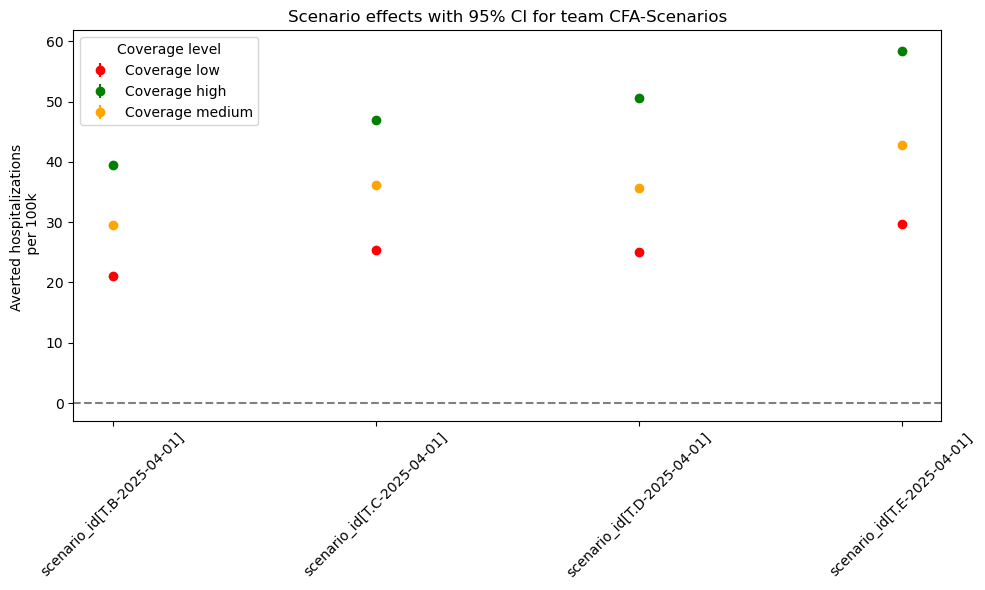

Could not fit model for team JHU_UNC-flepiMoP, coverage level nan: negative dimensions are not allowed

=== Mixed effects model summary for team JHU_UNC-flepiMoP and coverage level low ===
                   Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   outbreak_size_per_100k
No. Observations:    26910     Method:               REML                  
No. Groups:          18        Scale:                8982.1933             
Min. group size:     1495      Log-Likelihood:       -160717.4597          
Max. group size:     1495      Converged:            Yes                   
Mean group size:     1495.0                                                
---------------------------------------------------------------------------
                             Coef.   Std.Err.    z    P>|z|  [0.025  0.975]
---------------------------------------------------------------------------
Intercept                    210.016   21.353   9.835 0.000 168.164 25

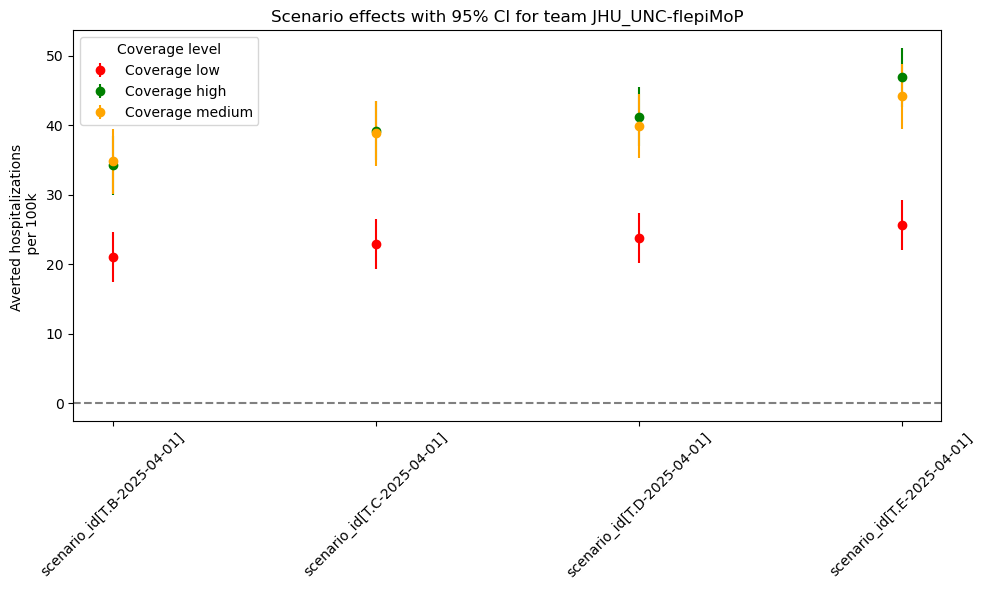

Could not fit model for team UIUC-IMMCYC, coverage level nan: negative dimensions are not allowed

=== Mixed effects model summary for team UIUC-IMMCYC and coverage level low ===
                   Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   outbreak_size_per_100k
No. Observations:    9000      Method:               REML                  
No. Groups:          18        Scale:                1382.4989             
Min. group size:     500       Log-Likelihood:       -45364.8073           
Max. group size:     500       Converged:            Yes                   
Mean group size:     500.0                                                 
---------------------------------------------------------------------------
                             Coef.   Std.Err.    z    P>|z|  [0.025  0.975]
---------------------------------------------------------------------------
Intercept                    336.545   12.176  27.639 0.000 312.679 360.410
scen

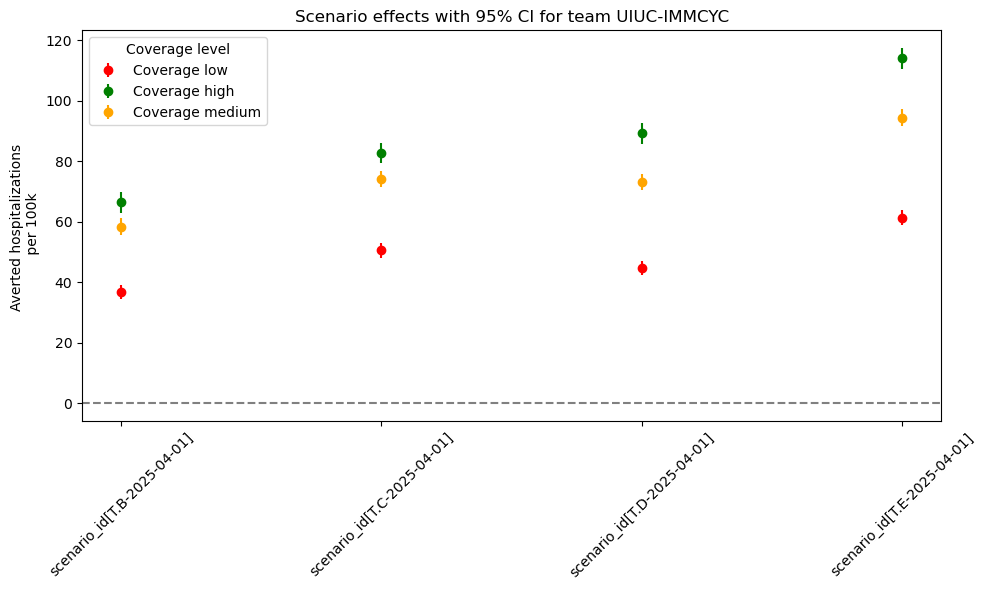

Could not fit model for team PSI-M_CoV_2025, coverage level nan: negative dimensions are not allowed

=== Mixed effects model summary for team PSI-M_CoV_2025 and coverage level low ===
                  Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   outbreak_size_per_100k
No. Observations:   27000     Method:               REML                  
No. Groups:         18        Scale:                2679.1932             
Min. group size:    1500      Log-Likelihood:       -144932.1728          
Max. group size:    1500      Converged:            Yes                   
Mean group size:    1500.0                                                
--------------------------------------------------------------------------
                             Coef.   Std.Err.   z    P>|z|  [0.025  0.975]
--------------------------------------------------------------------------
Intercept                    233.577   16.245 14.379 0.000 201.738 265.416
scenario_

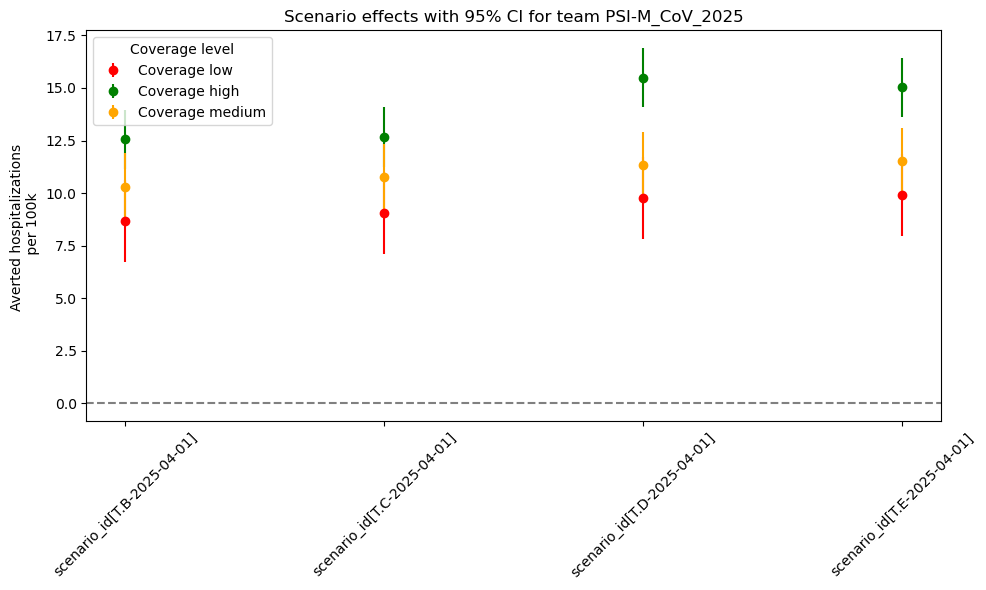

Could not fit model for team UNCC-Hierbin, coverage level nan: negative dimensions are not allowed

=== Mixed effects model summary for team UNCC-Hierbin and coverage level low ===
                  Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   outbreak_size_per_100k
No. Observations:   9000      Method:               REML                  
No. Groups:         18        Scale:                456.0101              
Min. group size:    500       Log-Likelihood:       -40370.1384           
Max. group size:    500       Converged:            Yes                   
Mean group size:    500.0                                                 
--------------------------------------------------------------------------
                             Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
--------------------------------------------------------------------------
Intercept                   124.173    4.826  25.728 0.000 114.714 133.633
scenario_id[T

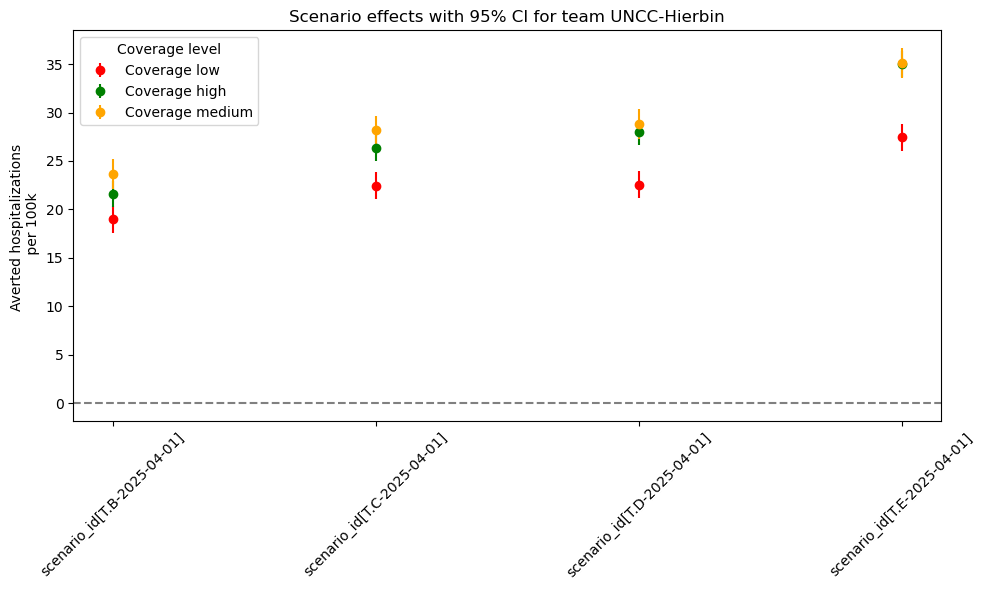

Could not fit model for team UVA-adaptive, coverage level nan: negative dimensions are not allowed

=== Mixed effects model summary for team UVA-adaptive and coverage level low ===
                   Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   outbreak_size_per_100k
No. Observations:    9000      Method:               REML                  
No. Groups:          18        Scale:                166.7089              
Min. group size:     500       Log-Likelihood:       -35865.5759           
Max. group size:     500       Converged:            Yes                   
Mean group size:     500.0                                                 
---------------------------------------------------------------------------
                             Coef.   Std.Err.    z    P>|z|  [0.025  0.975]
---------------------------------------------------------------------------
Intercept                    208.574   10.067  20.719 0.000 188.844 228.304
sc

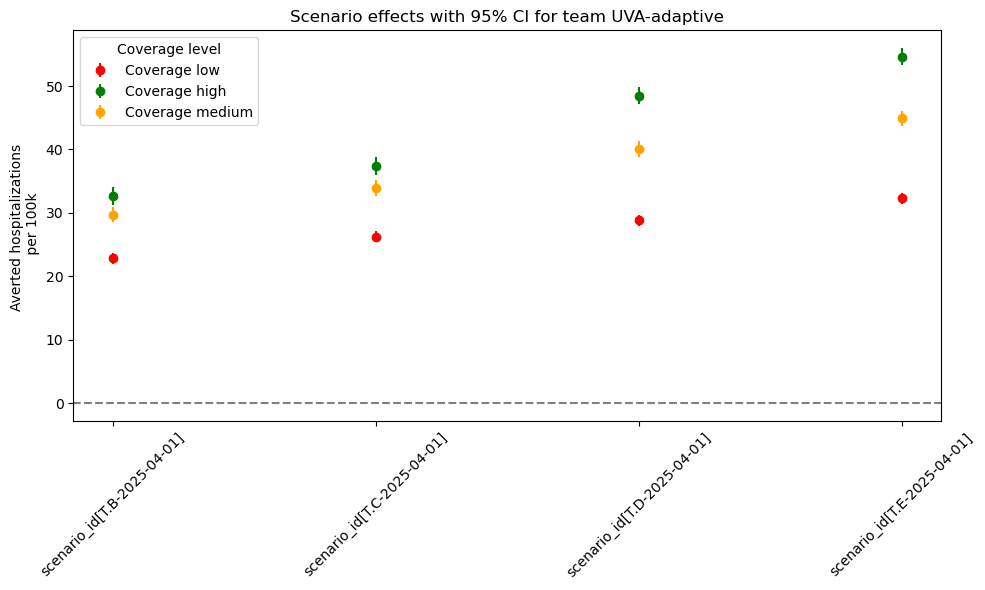

Could not fit model for team MOBS_NEU-GLEAM_COVID, coverage level nan: negative dimensions are not allowed

=== Mixed effects model summary for team MOBS_NEU-GLEAM_COVID and coverage level low ===
                   Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   outbreak_size_per_100k
No. Observations:    27000     Method:               REML                  
No. Groups:          18        Scale:                3474.3440             
Min. group size:     1500      Log-Likelihood:       -148430.5209          
Max. group size:     1500      Converged:            Yes                   
Mean group size:     1500.0                                                
---------------------------------------------------------------------------
                             Coef.   Std.Err.    z    P>|z|  [0.025  0.975]
---------------------------------------------------------------------------
Intercept                    191.271   10.585  18.070 0.000 17

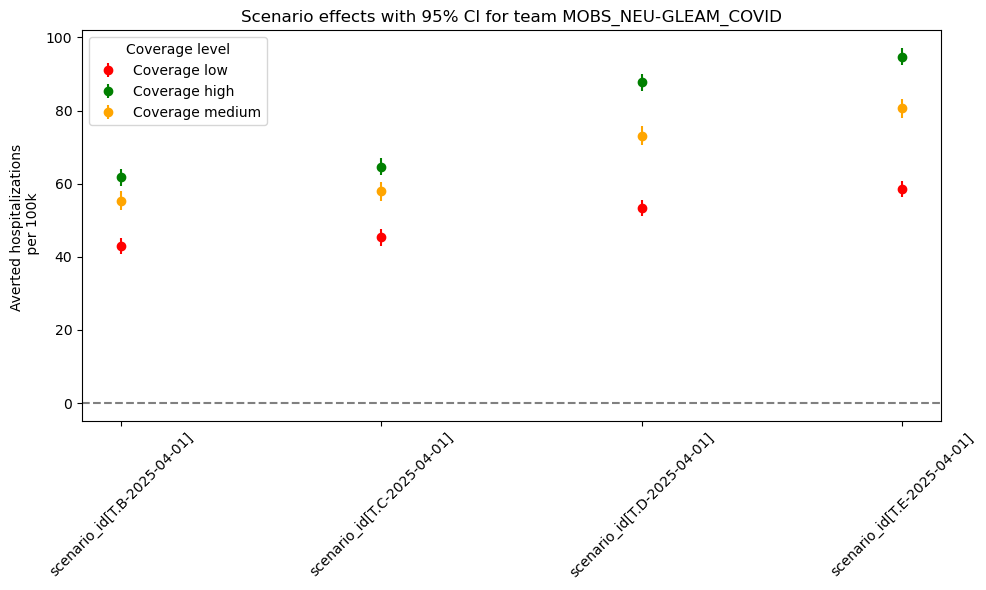

Could not fit model for team UT-ImmunoSEIRS, coverage level nan: negative dimensions are not allowed

=== Mixed effects model summary for team UT-ImmunoSEIRS and coverage level low ===
                   Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   outbreak_size_per_100k
No. Observations:    9000      Method:               REML                  
No. Groups:          18        Scale:                93.9556               
Min. group size:     500       Log-Likelihood:       -33287.0840           
Max. group size:     500       Converged:            Yes                   
Mean group size:     500.0                                                 
---------------------------------------------------------------------------
                             Coef.   Std.Err.    z    P>|z|  [0.025  0.975]
---------------------------------------------------------------------------
Intercept                     71.768    7.780   9.225 0.000  56.520  87.01

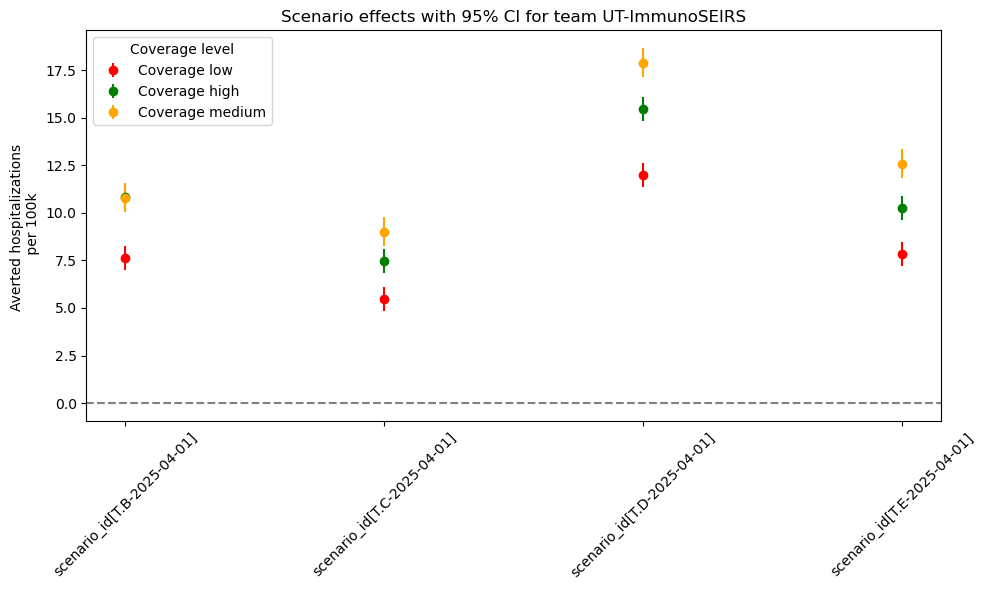

In [21]:
# Mixed effects model for each team separating out the coverage levels for the total outbreak size, i.e., not
# splitting them based on summer/winter dominant

teams = df["team"].unique()
df_filtered = df[(df["Coverage_level"].notna()) & (df["location"] != "US")]

# Get vac coverage levels 
loc_classes = df["Coverage_level"].unique()
colors_dict = {"low": "red", "medium": "orange", "high": "green"}

for team in teams:
    plt.figure(figsize=(10, 6))  # Start a new figure for each team
    
    for loc_class in loc_classes:
        # Filter by team, coverage level, and exclude US
        df_team = df_filtered[
            (df_filtered["team"] == team) &
            (df_filtered["Coverage_level"] == loc_class)
        ]

        try:
            # Fit mixed effects model
            model = smf.mixedlm(
                "outbreak_size_per_100k ~ scenario_id", 
                data=df_team, 
                groups=df_team["location"]
            )
            result = model.fit(method="powell")

            print(f"\n=== Mixed effects model summary for team {team} and coverage level {loc_class} ===")
            print(result.summary())

            coefs = result.params.filter(like="scenario_id")
            errors = result.bse.filter(like="scenario_id")

            # Plot with label for the legend
            plt.errorbar(
                coefs.index, np.abs(coefs.values), 
                yerr=1.96 * errors.values, 
                fmt='o', 
                label=f'Coverage {loc_class}', 
                color=colors_dict[loc_class]
            )

        except Exception as e:
            print(f"Could not fit model for team {team}, coverage level {loc_class}: {e}")

    # Finalize plot for this team
    plt.axhline(0, color='gray', linestyle='--')
    plt.xticks(rotation=45)
    plt.ylabel("Averted hospitalizations \n per 100k")
    #plt.ylim(-120, 1)
    plt.title(f"Scenario effects with 95% CI for team {team}")
    plt.legend(title="Coverage level")
    plt.tight_layout()
    plt.show()